In [1]:
# Verify that the new Kaggle runtime can execute CUDA

import torch

print("=" * 60)
print("NEW LAMNet NOTEBOOK GPU CHECK")
print("=" * 60)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

    x = torch.randn(100, 100, device="cuda:0")
    y = x @ x.T

    torch.cuda.synchronize()

    print("CUDA computation: PASSED")

NEW LAMNet NOTEBOOK GPU CHECK
PyTorch: 2.10.0+cu128
CUDA available: True
CUDA device count: 2
GPU: Tesla T4
CUDA computation: PASSED


In [3]:
# Verify the attached HAM10000 and trained-model datasets

from pathlib import Path

input_root = Path("/kaggle/input/datasets/akansha1009")

print("=" * 60)
print("LAMNet DATASET VERIFICATION")
print("=" * 60)

for item in sorted(input_root.iterdir()):
    print(item)

ham_path = input_root / "ham10000-preprocessed-segmentation"
models_path = input_root / "5-trained-models"

print("\nHAM10000 dataset exists:", ham_path.exists())
print("Five-model checkpoint dataset exists:", models_path.exists())

if ham_path.exists():
    print("\nHAM10000 contents:")
    for item in sorted(ham_path.iterdir()):
        print(" ", item.name)

if models_path.exists():
    print("\nFive-model checkpoint contents:")
    for item in sorted(models_path.iterdir()):
        print(" ", item.name)

LAMNet DATASET VERIFICATION
/kaggle/input/datasets/akansha1009/5-trained-models
/kaggle/input/datasets/akansha1009/ham10000-preprocessed-segmentation

HAM10000 dataset exists: True
Five-model checkpoint dataset exists: True

HAM10000 contents:
  test
  train
  validation

Five-model checkpoint contents:
  HAM10000_AlexNet_Balanced_Baseline_Backup
  HAM10000_EfficientNetB0_Balanced_Baseline_Backup
  HAM10000_ResNet50_Balanced_Baseline_Backup
  HAM10000_VGG16_Balanced_Baseline_Backup
  HAM10000_VGG19_Balanced_Baseline_Backup


In [4]:
# Verify the frozen HAM10000 train, validation, and test splits

from pathlib import Path
import numpy as np
import pandas as pd

ham_path = Path("/kaggle/input/datasets/akansha1009/ham10000-preprocessed-segmentation")

split_names = ["train", "validation", "test"]

print("=" * 60)
print("HAM10000 FROZEN SPLIT VERIFICATION")
print("=" * 60)

for split in split_names:
    split_path = ham_path / split

    images_path = split_path / "images.npy"
    masks_path = split_path / "masks.npy"
    metadata_path = split_path / "metadata.csv"

    images = np.load(images_path, mmap_mode="r")
    masks = np.load(masks_path, mmap_mode="r")
    metadata = pd.read_csv(metadata_path)

    print(f"\n{split.upper()}")
    print(f"Images shape:   {images.shape}")
    print(f"Masks shape:    {masks.shape}")
    print(f"Metadata shape: {metadata.shape}")
    print(f"Metadata columns: {list(metadata.columns)}")

HAM10000 FROZEN SPLIT VERIFICATION

TRAIN
Images shape:   (6981, 224, 224, 3)
Masks shape:    (6981, 224, 224)
Metadata shape: (6981, 2)
Metadata columns: ['image_id', 'dx']

VALIDATION
Images shape:   (1532, 224, 224, 3)
Masks shape:    (1532, 224, 224)
Metadata shape: (1532, 2)
Metadata columns: ['image_id', 'dx']

TEST
Images shape:   (1502, 224, 224, 3)
Masks shape:    (1502, 224, 224)
Metadata shape: (1502, 2)
Metadata columns: ['image_id', 'dx']


In [5]:
# Verify the frozen HAM10000 melanoma versus non-melanoma labels

import pandas as pd

print("=" * 60)
print("HAM10000 BINARY LABEL VERIFICATION")
print("=" * 60)

for split in ["train", "validation", "test"]:

    metadata_path = ham_path / split / "metadata.csv"
    metadata = pd.read_csv(metadata_path)

    binary_labels = (metadata["dx"] == "mel").astype(int)

    melanoma_count = int(binary_labels.sum())
    non_melanoma_count = int((binary_labels == 0).sum())

    print(f"\n{split.upper()}")
    print(f"Total:          {len(binary_labels):,}")
    print(f"Melanoma:       {melanoma_count:,}")
    print(f"Non-melanoma:   {non_melanoma_count:,}")
    print(f"Binary labels:  {sorted(binary_labels.unique().tolist())}")

    print("Original diagnoses:")
    print(metadata["dx"].value_counts().sort_index().to_dict())

HAM10000 BINARY LABEL VERIFICATION

TRAIN
Total:          6,981
Melanoma:       773
Non-melanoma:   6,208
Binary labels:  [0, 1]
Original diagnoses:
{'akiec': 222, 'bcc': 361, 'bkl': 772, 'df': 71, 'mel': 773, 'nv': 4683, 'vasc': 99}

VALIDATION
Total:          1,532
Melanoma:       173
Non-melanoma:   1,359
Binary labels:  [0, 1]
Original diagnoses:
{'akiec': 53, 'bcc': 82, 'bkl': 160, 'df': 24, 'mel': 173, 'nv': 1018, 'vasc': 22}

TEST
Total:          1,502
Melanoma:       167
Non-melanoma:   1,335
Binary labels:  [0, 1]
Original diagnoses:
{'akiec': 52, 'bcc': 71, 'bkl': 167, 'df': 20, 'mel': 167, 'nv': 1004, 'vasc': 21}


In [6]:
# Verify HAM10000 stored image ranges and basic statistics

import numpy as np

for split in ["train", "validation", "test"]:

    images_path = ham_path / split / "images.npy"
    images = np.load(images_path, mmap_mode="r")

    sample = np.asarray(images[:100], dtype=np.float32)

    print(f"\n{split.upper()}")
    print(f"Data type: {images.dtype}")
    print(f"Minimum: {sample.min():.6f}")
    print(f"Maximum: {sample.max():.6f}")
    print(f"Mean: {sample.mean():.6f}")
    print(f"Std: {sample.std():.6f}")


TRAIN
Data type: float32
Minimum: 0.000000
Maximum: 1.000000
Mean: 0.587564
Std: 0.167680

VALIDATION
Data type: float32
Minimum: 0.000000
Maximum: 1.000000
Mean: 0.615255
Std: 0.142007

TEST
Data type: float32
Minimum: 0.000000
Maximum: 1.000000
Mean: 0.625355
Std: 0.154172


In [7]:
# Create the reusable HAM10000 classification dataset for LAMNet

from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import numpy as np
import torch

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])


class HAM10000ClassificationDataset(Dataset):

    def __init__(self, split_path, transform=None):
        self.split_path = split_path
        self.transform = transform

        self.images = np.load(
            split_path / "images.npy",
            mmap_mode="r"
        )

        self.metadata = pd.read_csv(
            split_path / "metadata.csv"
        )

        self.labels = (
            self.metadata["dx"] == "mel"
        ).astype(np.int64).to_numpy()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):

        image = np.asarray(
            self.images[index],
            dtype=np.float32
        )

        image = np.clip(image, 0.0, 1.0)

        image = (image * 255).astype(np.uint8)

        if self.transform is not None:
            image = self.transform(image)
        else:
            image = torch.from_numpy(
                image.transpose(2, 0, 1)
            ).float() / 255.0

        label = torch.tensor(
            self.labels[index],
            dtype=torch.long
        )

        return image, label


train_dataset = HAM10000ClassificationDataset(
    ham_path / "train",
    transform=train_transform
)

val_dataset = HAM10000ClassificationDataset(
    ham_path / "validation",
    transform=eval_transform
)

test_dataset = HAM10000ClassificationDataset(
    ham_path / "test",
    transform=eval_transform
)

print("=" * 60)
print("LAMNet HAM10000 DATASETS READY")
print("=" * 60)
print(f"Train samples: {len(train_dataset):,}")
print(f"Validation samples: {len(val_dataset):,}")
print(f"Test samples: {len(test_dataset):,}")

LAMNet HAM10000 DATASETS READY
Train samples: 6,981
Validation samples: 1,532
Test samples: 1,502


In [8]:
# Create the balanced sampler used for LAMNet training

from torch.utils.data import WeightedRandomSampler

train_labels = train_dataset.labels

class_counts = np.bincount(
    train_labels,
    minlength=2
)

class_weights = 1.0 / class_counts

sample_weights = class_weights[train_labels]

balanced_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(
        sample_weights,
        dtype=torch.double
    ),
    num_samples=len(train_labels),
    replacement=True
)

print("=" * 60)
print("LAMNet BALANCED SAMPLER READY")
print("=" * 60)
print(f"Total training samples: {len(train_labels):,}")
print(f"Non-melanoma samples: {class_counts[0]:,}")
print(f"Melanoma samples: {class_counts[1]:,}")
print(f"Class weights: {class_weights}")
print(f"Samples drawn per epoch: {len(balanced_sampler):,}")
print("Replacement sampling: True")

LAMNet BALANCED SAMPLER READY
Total training samples: 6,981
Non-melanoma samples: 6,208
Melanoma samples: 773
Class weights: [0.00016108 0.00129366]
Samples drawn per epoch: 6,981
Replacement sampling: True


In [9]:
# Create GPU-ready DataLoaders for LAMNet

from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = 2

lamnet_train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=balanced_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

lamnet_val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

lamnet_test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("=" * 60)
print("LAMNet GPU DATALOADERS READY")
print("=" * 60)
print(f"Train batches: {len(lamnet_train_loader)}")
print(f"Validation batches: {len(lamnet_val_loader)}")
print(f"Test batches: {len(lamnet_test_loader)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Workers: {NUM_WORKERS}")
print("Pin memory: True")

LAMNet GPU DATALOADERS READY
Train batches: 219
Validation batches: 48
Test batches: 47
Batch size: 32
Workers: 2
Pin memory: True


In [11]:
# Configure the healthy Kaggle GPU device for LAMNet

import torch

device = torch.device("cuda:0")

print("=" * 60)
print("LAMNet GPU DEVICE READY")
print("=" * 60)
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"GPU count: {torch.cuda.device_count()}")

LAMNet GPU DEVICE READY
Device: cuda:0
GPU: Tesla T4
GPU count: 2


In [13]:
# Define the exact LAMNet architecture used in our research protocol

import torch
import torch.nn as nn


class ChannelAttention(nn.Module):

    def __init__(self, channels, reduction=16):
        super().__init__()

        hidden_channels = max(channels // reduction, 1)

        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, channels, kernel_size=1, bias=False)
        )

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_attention = self.mlp(self.avg_pool(x))
        max_attention = self.mlp(self.max_pool(x))

        attention = avg_attention + max_attention

        return self.sigmoid(attention)


class SpatialAttention(nn.Module):

    def __init__(self, kernel_size=7):
        super().__init__()

        padding = kernel_size // 2

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size=kernel_size,
            padding=padding,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_attention = torch.mean(
            x,
            dim=1,
            keepdim=True
        )

        max_attention, _ = torch.max(
            x,
            dim=1,
            keepdim=True
        )

        attention = torch.cat(
            [avg_attention, max_attention],
            dim=1
        )

        attention = self.conv(attention)

        return self.sigmoid(attention)


class AttentionBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        self.channel_attention = ChannelAttention(
            out_channels
        )

        self.spatial_attention = SpatialAttention()

        if in_channels != out_channels or stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        channel_attention = self.channel_attention(out)
        out = out * channel_attention

        spatial_attention = self.spatial_attention(out)
        out = out * spatial_attention

        out = out + identity
        out = self.relu(out)

        return out


class LAMNet(nn.Module):

    def __init__(self, num_classes=2):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        self.block1 = AttentionBlock(
            32,
            32
        )

        self.block2 = AttentionBlock(
            32,
            64,
            stride=2
        )

        self.block3 = AttentionBlock(
            64,
            128,
            stride=2
        )

        self.block4 = AttentionBlock(
            128,
            256,
            stride=2
        )

        self.block5 = AttentionBlock(
            256,
            256
        )

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.dropout = nn.Dropout(p=0.30)

        self.classifier = nn.Linear(
            256,
            num_classes
        )

    def forward(self, x):

        x = self.stem(x)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)

        x = self.global_pool(x)
        x = torch.flatten(x, 1)

        x = self.dropout(x)

        return self.classifier(x)


lamnet = LAMNet(num_classes=2).to(device)

parameter_count = sum(
    parameter.numel()
    for parameter in lamnet.parameters()
    if parameter.requires_grad
)

print("=" * 60)
print("LAMNet ARCHITECTURE READY")
print("=" * 60)
print(f"Trainable parameters: {parameter_count:,}")
print(f"Device: {device}")

LAMNet ARCHITECTURE READY
Trainable parameters: 2,427,148
Device: cuda:0


In [14]:
# Verify a real HAM10000 batch can pass through LAMNet on the healthy GPU

import torch

images, labels = next(iter(lamnet_train_loader))

images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

lamnet.eval()

with torch.no_grad():
    outputs = lamnet(images)

torch.cuda.synchronize()

print("=" * 60)
print("LAMNet GPU FORWARD PASS CHECK")
print("=" * 60)
print(f"Input shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Output shape: {outputs.shape}")
print(f"Input device: {images.device}")
print(f"Output device: {outputs.device}")
print(f"Output dtype: {outputs.dtype}")

if outputs.shape == (images.shape[0], 2):
    print("GPU forward pass: PASSED")
else:
    print("GPU forward pass: FAILED")

LAMNet GPU FORWARD PASS CHECK
Input shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Output shape: torch.Size([32, 2])
Input device: cuda:0
Output device: cuda:0
Output dtype: torch.float32
GPU forward pass: PASSED


In [15]:
# Configure the official LAMNet training protocol

import torch
import torch.nn as nn
import torch.optim as optim

SEED = 42
NUM_CLASSES = 2
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    lamnet.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("=" * 60)
print("LAMNet TRAINING CONFIGURATION")
print("=" * 60)
print(f"Device: {device}")
print(f"GPUs available: {torch.cuda.device_count()}")
print(f"Trainable parameters: {sum(p.numel() for p in lamnet.parameters() if p.requires_grad):,}")
print(f"Seed: {SEED}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Weight decay: {WEIGHT_DECAY}")
print(f"Maximum epochs: {MAX_EPOCHS}")
print(f"Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print("Loss: CrossEntropyLoss")
print("Optimizer: AdamW")
print("Scheduler: ReduceLROnPlateau")
print("Model selection: Validation F1")

LAMNet TRAINING CONFIGURATION
Device: cuda:0
GPUs available: 2
Trainable parameters: 2,427,148
Seed: 42
Batch size: 32
Learning rate: 0.0001
Weight decay: 1e-05
Maximum epochs: 20
Early stopping patience: 5
Loss: CrossEntropyLoss
Optimizer: AdamW
Scheduler: ReduceLROnPlateau
Model selection: Validation F1


In [16]:
# Prepare the directory for LAMNet training artifacts

from pathlib import Path

lamnet_output_dir = Path("/kaggle/working/LAMNet_HAM10000")

lamnet_output_dir.mkdir(
    parents=True,
    exist_ok=True
)

best_model_path = lamnet_output_dir / "lamnet_ham10000_best.pth"
history_path = lamnet_output_dir / "lamnet_ham10000_training_history.pt"
results_path = lamnet_output_dir / "lamnet_ham10000_results.json"

print("=" * 60)
print("LAMNet ARTIFACT STORAGE READY")
print("=" * 60)
print(f"Output directory: {lamnet_output_dir}")
print(f"Best model: {best_model_path}")
print(f"Training history: {history_path}")
print(f"Results: {results_path}")

LAMNet ARTIFACT STORAGE READY
Output directory: /kaggle/working/LAMNet_HAM10000
Best model: /kaggle/working/LAMNet_HAM10000/lamnet_ham10000_best.pth
Training history: /kaggle/working/LAMNet_HAM10000/lamnet_ham10000_training_history.pt
Results: /kaggle/working/LAMNet_HAM10000/lamnet_ham10000_results.json


In [17]:
# Train LAMNet on the frozen HAM10000 training split and save the best validation-F1 checkpoint

import time
import copy
import json
import torch

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

    return running_loss / total_samples


def evaluate_model(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_labels = []
    all_probs = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probabilities = torch.softmax(outputs, dim=1)[:, 1]
            predictions = torch.argmax(outputs, dim=1)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            total_samples += batch_size

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probabilities.cpu().numpy())
            all_preds.extend(predictions.cpu().numpy())

    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score,
        confusion_matrix
    )

    labels_np = all_labels
    probs_np = all_probs
    preds_np = all_preds

    metrics = {
        "loss": running_loss / total_samples,
        "accuracy": accuracy_score(labels_np, preds_np),
        "precision": precision_score(labels_np, preds_np, zero_division=0),
        "recall": recall_score(labels_np, preds_np, zero_division=0),
        "f1": f1_score(labels_np, preds_np, zero_division=0),
        "roc_auc": roc_auc_score(labels_np, probs_np),
        "confusion_matrix": confusion_matrix(labels_np, preds_np).tolist()
    }

    return metrics


training_history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
    "val_roc_auc": [],
    "learning_rate": []
}

best_val_f1 = -1.0
best_epoch = 0
best_state_dict = None
epochs_without_improvement = 0

start_time = time.time()

print("=" * 70)
print("LAMNet OFFICIAL HAM10000 TRAINING")
print("=" * 70)

for epoch in range(1, MAX_EPOCHS + 1):

    epoch_start = time.time()

    train_loss = train_one_epoch(
        lamnet,
        lamnet_train_loader,
        criterion,
        optimizer,
        device
    )

    val_metrics = evaluate_model(
        lamnet,
        lamnet_val_loader,
        criterion,
        device
    )

    current_lr = optimizer.param_groups[0]["lr"]

    training_history["epoch"].append(epoch)
    training_history["train_loss"].append(train_loss)
    training_history["val_loss"].append(val_metrics["loss"])
    training_history["val_accuracy"].append(val_metrics["accuracy"])
    training_history["val_precision"].append(val_metrics["precision"])
    training_history["val_recall"].append(val_metrics["recall"])
    training_history["val_f1"].append(val_metrics["f1"])
    training_history["val_roc_auc"].append(val_metrics["roc_auc"])
    training_history["learning_rate"].append(current_lr)

    scheduler.step(val_metrics["f1"])

    improved = val_metrics["f1"] > best_val_f1

    if improved:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch
        epochs_without_improvement = 0
        best_state_dict = copy.deepcopy(lamnet.state_dict())

        torch.save(
            {
                "model_name": "LAMNet",
                "dataset": "HAM10000",
                "task": "binary melanoma vs non-melanoma",
                "epoch": epoch,
                "best_validation_f1": best_val_f1,
                "model_state_dict": best_state_dict,
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "seed": SEED,
                "batch_size": BATCH_SIZE,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY
            },
            best_model_path
        )
    else:
        epochs_without_improvement += 1

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"Train Loss {train_loss:.4f} | "
        f"Val Loss {val_metrics['loss']:.4f} | "
        f"Val Acc {val_metrics['accuracy']:.4f} | "
        f"Val F1 {val_metrics['f1']:.4f} | "
        f"Val AUC {val_metrics['roc_auc']:.4f} | "
        f"LR {current_lr:.2e} | "
        f"Time {epoch_time / 60:.2f} min"
    )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print()
        print(
            f"Early stopping triggered after {EARLY_STOPPING_PATIENCE} "
            f"epochs without validation F1 improvement."
        )
        break

training_time = time.time() - start_time

print()
print("=" * 70)
print("LAMNet TRAINING COMPLETE")
print("=" * 70)
print(f"Best epoch: {best_epoch}")
print(f"Best validation F1: {best_val_f1:.4f}")
print(f"Epochs completed: {len(training_history['epoch'])}")
print(f"Training time: {training_time / 60:.2f} minutes")

if best_state_dict is not None:
    lamnet.load_state_dict(best_state_dict)

torch.save(training_history, history_path)

training_summary = {
    "model": "LAMNet",
    "dataset": "HAM10000",
    "task": "binary melanoma vs non-melanoma",
    "best_epoch": best_epoch,
    "best_validation_f1": best_val_f1,
    "epochs_completed": len(training_history["epoch"]),
    "training_time_minutes": training_time / 60,
    "seed": SEED,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "optimizer": "AdamW",
    "loss": "CrossEntropyLoss",
    "scheduler": "ReduceLROnPlateau",
    "model_selection_metric": "validation_f1",
    "num_parameters": sum(
        p.numel() for p in lamnet.parameters()
        if p.requires_grad
    )
}

with open(results_path, "w") as f:
    json.dump(training_summary, f, indent=2)

print()
print("Saved artifacts:")
print(f"Best checkpoint: {best_model_path}")
print(f"Training history: {history_path}")
print(f"Training summary: {results_path}")

LAMNet OFFICIAL HAM10000 TRAINING
Epoch 01/20 | Train Loss 0.5512 | Val Loss 0.3904 | Val Acc 0.8101 | Val F1 0.4831 | Val AUC 0.8767 | LR 1.00e-04 | Time 1.05 min
Epoch 02/20 | Train Loss 0.4915 | Val Loss 0.4225 | Val Acc 0.7578 | Val F1 0.4404 | Val AUC 0.8767 | LR 1.00e-04 | Time 0.69 min
Epoch 03/20 | Train Loss 0.4792 | Val Loss 0.4808 | Val Acc 0.7134 | Val F1 0.4185 | Val AUC 0.8982 | LR 1.00e-04 | Time 0.60 min
Epoch 04/20 | Train Loss 0.4680 | Val Loss 0.4970 | Val Acc 0.6984 | Val F1 0.4137 | Val AUC 0.8990 | LR 1.00e-04 | Time 0.57 min
Epoch 05/20 | Train Loss 0.4455 | Val Loss 0.4852 | Val Acc 0.7010 | Val F1 0.4158 | Val AUC 0.9061 | LR 5.00e-05 | Time 0.55 min
Epoch 06/20 | Train Loss 0.4397 | Val Loss 0.3681 | Val Acc 0.7911 | Val F1 0.4684 | Val AUC 0.9007 | LR 5.00e-05 | Time 0.55 min

Early stopping triggered after 5 epochs without validation F1 improvement.

LAMNet TRAINING COMPLETE
Best epoch: 1
Best validation F1: 0.4831
Epochs completed: 6
Training time: 3.99 min

In [18]:
# Verify the saved LAMNet checkpoint before official test evaluation

from pathlib import Path
import torch

checkpoint = torch.load(
    best_model_path,
    map_location="cpu",
    weights_only=False
)

print("=" * 60)
print("LAMNet CHECKPOINT VERIFICATION")
print("=" * 60)
print(f"File exists: {best_model_path.exists()}")
print(f"File size: {best_model_path.stat().st_size / (1024 ** 2):.2f} MB")
print(f"Model name: {checkpoint['model_name']}")
print(f"Dataset: {checkpoint['dataset']}")
print(f"Task: {checkpoint['task']}")
print(f"Best epoch: {checkpoint['epoch']}")
print(f"Best validation F1: {checkpoint['best_validation_f1']:.4f}")
print(f"Seed: {checkpoint['seed']}")
print(f"Batch size: {checkpoint['batch_size']}")
print(f"Learning rate: {checkpoint['learning_rate']}")
print(f"Weight decay: {checkpoint['weight_decay']}")

state_dict = checkpoint["model_state_dict"]

print(f"State dictionary entries: {len(state_dict)}")

if checkpoint["model_name"] == "LAMNet" and checkpoint["epoch"] == best_epoch:
    print("Checkpoint verification: PASSED")
else:
    print("Checkpoint verification: FAILED")

LAMNet CHECKPOINT VERIFICATION
File exists: True
File size: 27.88 MB
Model name: LAMNet
Dataset: HAM10000
Task: binary melanoma vs non-melanoma
Best epoch: 1
Best validation F1: 0.4831
Seed: 42
Batch size: 32
Learning rate: 0.0001
Weight decay: 1e-05
State dictionary entries: 101
Checkpoint verification: PASSED


In [19]:
# Load the verified best LAMNet checkpoint for official HAM10000 test evaluation

import torch

checkpoint = torch.load(
    best_model_path,
    map_location=device,
    weights_only=False
)

lamnet.load_state_dict(checkpoint["model_state_dict"])
lamnet = lamnet.to(device)
lamnet.eval()

print("=" * 60)
print("LAMNet BEST CHECKPOINT LOADED")
print("=" * 60)
print(f"Checkpoint epoch: {checkpoint['epoch']}")
print(f"Validation F1: {checkpoint['best_validation_f1']:.4f}")
print(f"Model device: {next(lamnet.parameters()).device}")
print(f"Model parameters: {sum(p.numel() for p in lamnet.parameters()):,}")

print("Checkpoint loading: PASSED")

LAMNet BEST CHECKPOINT LOADED
Checkpoint epoch: 1
Validation F1: 0.4831
Model device: cuda:0
Model parameters: 2,427,148
Checkpoint loading: PASSED


In [20]:
# Evaluate the frozen best LAMNet checkpoint on the untouched HAM10000 test split

import json
import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

lamnet.eval()

test_loss = 0.0
total_samples = 0

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in lamnet_test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = lamnet(images)
        loss = criterion(outputs, labels)

        probabilities = torch.softmax(outputs, dim=1)[:, 1]
        predictions = torch.argmax(outputs, dim=1)

        batch_size = labels.size(0)

        test_loss += loss.item() * batch_size
        total_samples += batch_size

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probabilities.cpu().numpy())
        all_preds.extend(predictions.cpu().numpy())

test_loss /= total_samples

test_accuracy = accuracy_score(all_labels, all_preds)
test_precision = precision_score(
    all_labels, all_preds, zero_division=0
)
test_recall = recall_score(
    all_labels, all_preds, zero_division=0
)
test_f1 = f1_score(
    all_labels, all_preds, zero_division=0
)
test_roc_auc = roc_auc_score(
    all_labels, all_probs
)
test_cm = confusion_matrix(
    all_labels, all_preds
)

lamnet_test_results = {
    "model": "LAMNet",
    "dataset": "HAM10000",
    "task": "binary melanoma vs non-melanoma",
    "best_epoch": checkpoint["epoch"],
    "best_validation_f1": checkpoint["best_validation_f1"],
    "test_loss": test_loss,
    "test_accuracy": test_accuracy,
    "test_precision": test_precision,
    "test_recall": test_recall,
    "test_f1": test_f1,
    "test_roc_auc": test_roc_auc,
    "confusion_matrix": test_cm.tolist(),
    "seed": SEED,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY
}

with open(results_path, "w") as f:
    json.dump(lamnet_test_results, f, indent=2)

print("=" * 70)
print("LAMNet OFFICIAL HAM10000 TEST RESULTS")
print("=" * 70)
print(f"Test samples: {total_samples}")
print(f"Test Loss: {test_loss:.6f}")
print(f"Accuracy: {test_accuracy:.6f}")
print(f"Precision: {test_precision:.6f}")
print(f"Recall: {test_recall:.6f}")
print(f"F1 Score: {test_f1:.6f}")
print(f"ROC-AUC: {test_roc_auc:.6f}")
print()
print("Confusion Matrix:")
print(test_cm)
print()
print(f"Results saved to: {results_path}")

LAMNet OFFICIAL HAM10000 TEST RESULTS
Test samples: 1502
Test Loss: 0.413588
Accuracy: 0.772304
Precision: 0.285012
Recall: 0.694611
F1 Score: 0.404181
ROC-AUC: 0.819673

Confusion Matrix:
[[1044  291]
 [  51  116]]

Results saved to: /kaggle/working/LAMNet_HAM10000/lamnet_ham10000_results.json


In [21]:
# Create a complete backup of the official LAMNet HAM10000 experiment

import shutil
from pathlib import Path

backup_path = Path("/kaggle/working/LAMNet_HAM10000_Baseline_Backup.zip")

if backup_path.exists():
    backup_path.unlink()

shutil.make_archive(
    base_name=str(backup_path.with_suffix("")),
    format="zip",
    root_dir=str(lamnet_output_dir)
)

print("=" * 60)
print("LAMNet BACKUP CREATED")
print("=" * 60)
print(f"Backup path: {backup_path}")
print(f"Backup size: {backup_path.stat().st_size / (1024 ** 2):.2f} MB")
print(f"Backup exists: {backup_path.exists()}")

LAMNet BACKUP CREATED
Backup path: /kaggle/working/LAMNet_HAM10000_Baseline_Backup.zip
Backup size: 25.50 MB
Backup exists: True


In [22]:
# Verify that the LAMNet backup contains all required experiment artifacts

import zipfile

required_files = {
    "lamnet_ham10000_best.pth",
    "lamnet_ham10000_training_history.pt",
    "lamnet_ham10000_results.json"
}

with zipfile.ZipFile(backup_path, "r") as zip_file:
    contents = zip_file.namelist()

print("=" * 60)
print("LAMNet BACKUP VERIFICATION")
print("=" * 60)

for file_name in contents:
    print(f"✓ {file_name}")

missing_files = required_files - {
    file_name.split("/")[-1] for file_name in contents
}

print()
print(f"Files in backup: {len(contents)}")

if not missing_files:
    print("Backup verification: PASSED")
    print("All required LAMNet artifacts are present.")
else:
    print("Backup verification: FAILED")
    print(f"Missing files: {sorted(missing_files)}")

LAMNet BACKUP VERIFICATION
✓ lamnet_ham10000_training_history.pt
✓ lamnet_ham10000_best.pth
✓ lamnet_ham10000_results.json

Files in backup: 3
Backup verification: PASSED
All required LAMNet artifacts are present.


In [23]:
# Create the frozen six-model HAM10000 benchmark table

import pandas as pd

ham10000_benchmark = pd.DataFrame([
    {
        "Model": "AlexNet",
        "Accuracy": 0.845539,
        "Precision": 0.385965,
        "Recall": 0.658683,
        "F1": 0.486726,
        "ROC-AUC": 0.870407
    },
    {
        "Model": "VGG16",
        "Accuracy": 0.856192,
        "Precision": 0.415225,
        "Recall": 0.718563,
        "F1": 0.526316,
        "ROC-AUC": 0.896064
    },
    {
        "Model": "VGG19",
        "Accuracy": 0.903462,
        "Precision": 0.568750,
        "Recall": 0.544910,
        "F1": 0.556575,
        "ROC-AUC": 0.872484
    },
    {
        "Model": "ResNet50",
        "Accuracy": 0.881491,
        "Precision": 0.477178,
        "Recall": 0.688623,
        "F1": 0.563725,
        "ROC-AUC": 0.908995
    },
    {
        "Model": "EfficientNet-B0",
        "Accuracy": 0.895473,
        "Precision": 0.534722,
        "Recall": 0.461078,
        "F1": 0.495177,
        "ROC-AUC": 0.888434
    },
    {
        "Model": "LAMNet",
        "Accuracy": 0.772304,
        "Precision": 0.285012,
        "Recall": 0.694611,
        "F1": 0.404181,
        "ROC-AUC": 0.819673
    }
])

ham10000_benchmark = ham10000_benchmark.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("HAM10000 SIX-MODEL BENCHMARK")
print("=" * 70)

display(
    ham10000_benchmark.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

best_f1_model = ham10000_benchmark.loc[
    ham10000_benchmark["F1"].idxmax(),
    "Model"
]

best_auc_model = ham10000_benchmark.loc[
    ham10000_benchmark["ROC-AUC"].idxmax(),
    "Model"
]

print()
print(f"Best F1: {best_f1_model}")
print(f"Best ROC-AUC: {best_auc_model}")

HAM10000 SIX-MODEL BENCHMARK


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,ResNet50,0.8815,0.4772,0.6886,0.5637,0.9090
1,VGG19,0.9035,0.5687,0.5449,0.5566,0.8725
2,VGG16,0.8562,0.4152,0.7186,0.5263,0.8961
3,EfficientNet-B0,0.8955,0.5347,0.4611,0.4952,0.8884
4,AlexNet,0.8455,0.3860,0.6587,0.4867,0.8704
5,LAMNet,0.7723,0.2850,0.6946,0.4042,0.8197



Best F1: ResNet50
Best ROC-AUC: ResNet50


In [28]:
# Verify the attached frozen Derm7pt dataset and locate its files

from pathlib import Path

kaggle_input = Path("/kaggle/input")

print("=" * 70)
print("DERM7PT ATTACHMENT CHECK")
print("=" * 70)

for path in kaggle_input.iterdir():
    print(path)

print()
print("Searching for the frozen Derm7pt metadata...")

metadata_matches = list(
    kaggle_input.rglob("Derm7pt_split_metadata.csv")
)

image_dir_matches = [
    path for path in kaggle_input.rglob("Derm7pt_Kaggle_Ready")
    if path.is_dir()
]

print()
print("Metadata files found:")
for path in metadata_matches:
    print(path)

print()
print("Image directories found:")
for path in image_dir_matches:
    print(path)

if metadata_matches and image_dir_matches:
    print()
    print("Derm7pt attachment: PASSED")
else:
    print()
    print("Derm7pt attachment: NOT FULLY FOUND")

DERM7PT ATTACHMENT CHECK
/kaggle/input/datasets

Searching for the frozen Derm7pt metadata...

Metadata files found:
/kaggle/input/datasets/akansha1009/derm7pt-frozen-dataset/Derm7pt_split_metadata.csv

Image directories found:
/kaggle/input/datasets/akansha1009/derm7pt-frozen-dataset/Derm7pt_Kaggle_Ready

Derm7pt attachment: PASSED


In [29]:
# Build the frozen Derm7pt official test dataset and external evaluation loader

from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import torch
from torchvision import transforms

DERM_ROOT = Path(
    "/kaggle/input/datasets/akansha1009/derm7pt-frozen-dataset"
)

DERM_IMAGE_ROOT = DERM_ROOT / "Derm7pt_Kaggle_Ready" / "images"
DERM_METADATA_PATH = DERM_ROOT / "Derm7pt_split_metadata.csv"

derm_metadata = pd.read_csv(DERM_METADATA_PATH)

derm_test_metadata = derm_metadata[
    derm_metadata["split"].astype(str).str.lower() == "test"
].copy().reset_index(drop=True)

print("=" * 70)
print("DERM7PT FROZEN TEST SET")
print("=" * 70)
print(f"Total test cases: {len(derm_test_metadata)}")
print(
    "Non-Melanoma:",
    int((derm_test_metadata["binary_label"] == 0).sum())
)
print(
    "Melanoma:",
    int((derm_test_metadata["binary_label"] == 1).sum())
)


class Derm7ptExternalDataset(Dataset):
    def __init__(self, dataframe, image_root, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_root = Path(image_root)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = self.image_root / str(row["derm"])

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = torch.tensor(
            int(row["label"]),
            dtype=torch.long
        )

        return image, label


derm_eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

derm_lamnet_test_dataset = Derm7ptExternalDataset(
    dataframe=derm_test_metadata,
    image_root=DERM_IMAGE_ROOT,
    transform=derm_eval_transform
)

derm_lamnet_test_loader = DataLoader(
    derm_lamnet_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print()
print(f"Dataset length: {len(derm_lamnet_test_dataset)}")
print(f"Number of batches: {len(derm_lamnet_test_loader)}")
print("Shuffle: False")
print("Batch size: 32")
print("Transform: Resize → ToTensor → ImageNet normalization")

print()
print("Derm7pt test loader: READY")

DERM7PT FROZEN TEST SET
Total test cases: 395
Non-Melanoma: 0
Melanoma: 0

Dataset length: 395
Number of batches: 13
Shuffle: False
Batch size: 32
Transform: Resize → ToTensor → ImageNet normalization

Derm7pt test loader: READY


In [30]:
# Inspect the frozen Derm7pt label columns without modifying the metadata

print("=" * 70)
print("DERM7PT LABEL DIAGNOSTIC")
print("=" * 70)

print("binary_label unique values:")
print(derm_test_metadata["binary_label"].value_counts(dropna=False))

print()
print("label unique values:")
print(derm_test_metadata["label"].value_counts(dropna=False))

print()
print("diagnosis unique values:")
print(derm_test_metadata["diagnosis"].value_counts(dropna=False))

print()
print("First 10 label-related rows:")
display(
    derm_test_metadata[
        ["case_num", "diagnosis", "binary_label", "label", "split"]
    ].head(10)
)

DERM7PT LABEL DIAGNOSTIC
binary_label unique values:
binary_label
Non-Melanoma    294
Melanoma        101
Name: count, dtype: int64

label unique values:
label
0    294
1    101
Name: count, dtype: int64

diagnosis unique values:
diagnosis
clark nevus                     156
melanoma (less than 0.76 mm)     40
reed or spitz nevus              34
melanoma (in situ)               26
seborrheic keratosis             19
melanoma (0.76 to 1.5 mm)        18
basal cell carcinoma             16
melanoma (more than 1.5 mm)      15
vascular lesion                  13
lentigo                          12
blue nevus                       11
dermal nevus                      8
dermatofibroma                    7
melanosis                         6
combined nevus                    5
congenital nevus                  4
miscellaneous                     2
melanoma metastasis               1
recurrent nevus                   1
melanoma                          1
Name: count, dtype: int64

First 10 labe

,case_num,diagnosis,binary_label,label,split
0,4,basal cell carcinoma,Non-Melanoma,0,test
1,7,basal cell carcinoma,Non-Melanoma,0,test
2,9,basal cell carcinoma,Non-Melanoma,0,test
3,11,basal cell carcinoma,Non-Melanoma,0,test
4,15,basal cell carcinoma,Non-Melanoma,0,test
5,16,basal cell carcinoma,Non-Melanoma,0,test
6,21,basal cell carcinoma,Non-Melanoma,0,test
7,24,basal cell carcinoma,Non-Melanoma,0,test
8,29,basal cell carcinoma,Non-Melanoma,0,test
9,32,basal cell carcinoma,Non-Melanoma,0,test


In [31]:
# Perform the final Derm7pt label and tensor sanity check before LAMNet evaluation

import torch

print("=" * 70)
print("DERM7PT FINAL SANITY CHECK")
print("=" * 70)

print(
    "Numeric label counts:",
    derm_test_metadata["label"].value_counts().sort_index().to_dict()
)

images, labels = next(iter(derm_lamnet_test_loader))

images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

lamnet.eval()

with torch.no_grad():
    outputs = lamnet(images)

    probabilities = torch.softmax(outputs, dim=1)[:, 1]
    predictions = torch.argmax(outputs, dim=1)

torch.cuda.synchronize()

print()
print(f"Batch image shape: {images.shape}")
print(f"Batch label shape: {labels.shape}")
print(f"Output shape: {outputs.shape}")
print(f"Image device: {images.device}")
print(f"Output device: {outputs.device}")
print(f"Image dtype: {images.dtype}")
print(f"Output dtype: {outputs.dtype}")
print(f"First 10 true labels: {labels[:10].cpu().tolist()}")
print(
    f"First 10 melanoma probabilities: "
    f"{probabilities[:10].cpu().tolist()}"
)
print(f"First 10 predictions: {predictions[:10].cpu().tolist()}")

if (
    len(derm_test_metadata) == 395
    and int((derm_test_metadata["label"] == 0).sum()) == 294
    and int((derm_test_metadata["label"] == 1).sum()) == 101
    and outputs.shape == (images.shape[0], 2)
):
    print()
    print("Derm7pt final sanity check: PASSED")
else:
    print()
    print("Derm7pt final sanity check: FAILED")

DERM7PT FINAL SANITY CHECK
Numeric label counts: {0: 294, 1: 101}

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Output shape: torch.Size([32, 2])
Image device: cuda:0
Output device: cuda:0
Image dtype: torch.float32
Output dtype: torch.float32
First 10 true labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
First 10 melanoma probabilities: [0.676620602607727, 0.4922201633453369, 0.24017590284347534, 0.5173747539520264, 0.33960333466529846, 0.4847622513771057, 0.5702866315841675, 0.28643614053726196, 0.16159550845623016, 0.37450504302978516]
First 10 predictions: [1, 0, 0, 1, 0, 0, 1, 0, 0, 0]

Derm7pt final sanity check: PASSED


In [32]:
# Evaluate the frozen best LAMNet checkpoint on the untouched Derm7pt test set

import json
import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

lamnet.eval()

test_loss = 0.0
total_samples = 0

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in derm_lamnet_test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = lamnet(images)
        loss = criterion(outputs, labels)

        probabilities = torch.softmax(outputs, dim=1)[:, 1]
        predictions = torch.argmax(outputs, dim=1)

        batch_size = labels.size(0)

        test_loss += loss.item() * batch_size
        total_samples += batch_size

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probabilities.cpu().numpy())
        all_preds.extend(predictions.cpu().numpy())

test_loss /= total_samples

derm_accuracy = accuracy_score(all_labels, all_preds)
derm_precision = precision_score(
    all_labels, all_preds, zero_division=0
)
derm_recall = recall_score(
    all_labels, all_preds, zero_division=0
)
derm_f1 = f1_score(
    all_labels, all_preds, zero_division=0
)
derm_roc_auc = roc_auc_score(
    all_labels, all_probs
)
derm_cm = confusion_matrix(
    all_labels, all_preds
)

lamnet_derm7pt_results = {
    "model": "LAMNet",
    "dataset": "Derm7pt",
    "split": "official test",
    "task": "binary melanoma vs non-melanoma",
    "test_samples": total_samples,
    "test_loss": test_loss,
    "test_accuracy": derm_accuracy,
    "test_precision": derm_precision,
    "test_recall": derm_recall,
    "test_f1": derm_f1,
    "test_roc_auc": derm_roc_auc,
    "confusion_matrix": derm_cm.tolist(),
    "source_checkpoint_epoch": checkpoint["epoch"],
    "source_ham10000_validation_f1": checkpoint["best_validation_f1"]
}

derm_results_path = (
    lamnet_output_dir / "lamnet_derm7pt_external_results.json"
)

with open(derm_results_path, "w") as f:
    json.dump(lamnet_derm7pt_results, f, indent=2)

print("=" * 70)
print("LAMNet OFFICIAL DERM7PT EXTERNAL TEST RESULTS")
print("=" * 70)
print(f"Test samples: {total_samples}")
print(f"Test Loss: {test_loss:.6f}")
print(f"Accuracy: {derm_accuracy:.6f}")
print(f"Precision: {derm_precision:.6f}")
print(f"Recall: {derm_recall:.6f}")
print(f"F1 Score: {derm_f1:.6f}")
print(f"ROC-AUC: {derm_roc_auc:.6f}")
print()
print("Confusion Matrix:")
print(derm_cm)
print()
print(f"Results saved to: {derm_results_path}")

LAMNet OFFICIAL DERM7PT EXTERNAL TEST RESULTS
Test samples: 395
Test Loss: 0.692913
Accuracy: 0.600000
Precision: 0.358209
Recall: 0.712871
F1 Score: 0.476821
ROC-AUC: 0.723008

Confusion Matrix:
[[165 129]
 [ 29  72]]

Results saved to: /kaggle/working/LAMNet_HAM10000/lamnet_derm7pt_external_results.json


In [34]:
# Purpose: Verify the attached PAD-UFES-20 dataset and locate its metadata

from pathlib import Path

base = Path("/kaggle/input/datasets")

print("=" * 70)
print("PAD-UFES-20 ATTACHMENT CHECK")
print("=" * 70)

metadata_files = []

for path in base.rglob("metadata.csv"):
    if "pad" in str(path).lower() or "ufes" in str(path).lower():
        metadata_files.append(path)

if metadata_files:
    print("PAD-UFES-20 metadata found:")
    for path in metadata_files:
        print(path)
else:
    print("PAD-UFES-20 metadata.csv not found.")

print("\nPAD-UFES-20 related directories:")

found_dirs = set()

for path in base.rglob("*"):
    if path.is_dir() and ("pad" in path.name.lower() or "ufes" in path.name.lower()):
        found_dirs.add(path)

for path in sorted(found_dirs):
    print(path)

print("\nAttachment check complete.")

PAD-UFES-20 ATTACHMENT CHECK
PAD-UFES-20 metadata found:
/kaggle/input/datasets/maxjen/pad-ufes-20/PAD-UFES-20/metadata.csv

PAD-UFES-20 related directories:
/kaggle/input/datasets/maxjen/pad-ufes-20
/kaggle/input/datasets/maxjen/pad-ufes-20/PAD-UFES-20

Attachment check complete.


In [35]:
# Purpose: Verify PAD-UFES-20 metadata, image mapping, and melanoma labels

from pathlib import Path
import pandas as pd

PAD_ROOT = Path("/kaggle/input/datasets/maxjen/pad-ufes-20/PAD-UFES-20")
PAD_METADATA_PATH = PAD_ROOT / "metadata.csv"

pad_metadata = pd.read_csv(PAD_METADATA_PATH)

print("=" * 70)
print("PAD-UFES-20 DATASET VERIFICATION")
print("=" * 70)

print(f"Metadata shape: {pad_metadata.shape}")
print(f"Number of images: {len(pad_metadata)}")
print(f"Unique image IDs: {pad_metadata['img_id'].nunique()}")
print(f"Unique patients: {pad_metadata['patient_id'].nunique()}")
print(f"Unique lesions: {pad_metadata['lesion_id'].nunique()}")

print("\nDiagnostic distribution:")
print(pad_metadata["diagnostic"].value_counts())

pad_metadata["binary_label"] = (
    pad_metadata["diagnostic"].astype(str).str.upper() == "MEL"
).astype(int)

print("\nBinary label distribution:")
print(pad_metadata["binary_label"].value_counts().sort_index())

print("\nExpected:")
print("Non-Melanoma: 2246")
print("Melanoma:      52")

image_files = list(PAD_ROOT.rglob("*.png"))

print(f"\nPNG image files found: {len(image_files)}")

image_names = {path.stem for path in image_files}
metadata_names = set(pad_metadata["img_id"].astype(str))

missing_images = metadata_names - image_names
unlisted_images = image_names - metadata_names

print(f"Missing metadata-referenced images: {len(missing_images)}")
print(f"Unlisted PNG images: {len(unlisted_images)}")

print("\nVerification complete.")

PAD-UFES-20 DATASET VERIFICATION
Metadata shape: (2298, 26)
Number of images: 2298
Unique image IDs: 2298
Unique patients: 1373
Unique lesions: 1641

Diagnostic distribution:
diagnostic
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64

Binary label distribution:
binary_label
0    2246
1      52
Name: count, dtype: int64

Expected:
Non-Melanoma: 2246
Melanoma:      52

PNG image files found: 2298
Missing metadata-referenced images: 2298
Unlisted PNG images: 2298

Verification complete.


In [36]:
# Purpose: Identify the exact PAD-UFES-20 image directory and verify image filenames

from pathlib import Path

PAD_ROOT = Path("/kaggle/input/datasets/maxjen/pad-ufes-20/PAD-UFES-20")

print("=" * 70)
print("PAD-UFES-20 IMAGE LOCATION CHECK")
print("=" * 70)

image_files = list(PAD_ROOT.rglob("*.png"))

print(f"Total PNG images found: {len(image_files)}")

print("\nFirst 10 image paths:")
for path in image_files[:10]:
    print(path)

print("\nFirst 10 metadata image IDs:")
for img_id in pad_metadata["img_id"].astype(str).head(10):
    print(img_id)

if image_files:
    print("\nImage directory:")
    print(image_files[0].parent)

print("\nImage location check complete.")

PAD-UFES-20 IMAGE LOCATION CHECK
Total PNG images found: 2298

First 10 image paths:
/kaggle/input/datasets/maxjen/pad-ufes-20/PAD-UFES-20/Dataset/PAT_1726_3228_674.png
/kaggle/input/datasets/maxjen/pad-ufes-20/PAD-UFES-20/Dataset/PAT_492_937_958.png
/kaggle/input/datasets/maxjen/pad-ufes-20/PAD-UFES-20/Dataset/PAT_13_21_350.png
/kaggle/input/datasets/maxjen/pad-ufes-20/PAD-UFES-20/Dataset/PAT_650_3858_329.png
/kaggle/input/datasets/maxjen/pad-ufes-20/PAD-UFES-20/Dataset/PAT_456_887_499.png
/kaggle/input/datasets/maxjen/pad-ufes-20/PAD-UFES-20/Dataset/PAT_766_1444_52.png
/kaggle/input/datasets/maxjen/pad-ufes-20/PAD-UFES-20/Dataset/PAT_15_1001_749.png
/kaggle/input/datasets/maxjen/pad-ufes-20/PAD-UFES-20/Dataset/PAT_456_888_961.png
/kaggle/input/datasets/maxjen/pad-ufes-20/PAD-UFES-20/Dataset/PAT_806_1520_60.png
/kaggle/input/datasets/maxjen/pad-ufes-20/PAD-UFES-20/Dataset/PAT_1913_3815_367.png

First 10 metadata image IDs:
PAT_1516_1765_530.png
PAT_46_881_939.png
PAT_1545_1867_547.png

In [37]:
# Purpose: Build the PAD-UFES-20 external evaluation dataset and DataLoader for LAMNet

from PIL import Image
from torch.utils.data import Dataset, DataLoader

PAD_IMAGE_ROOT = PAD_ROOT / "Dataset"

class PADUFES20ExternalDataset(Dataset):
    def __init__(self, dataframe, image_root, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_root = Path(image_root)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = self.image_root / str(row["img_id"])
        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = torch.tensor(
            int(row["binary_label"]),
            dtype=torch.long
        )

        return image, label


pad_eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

pad_lamnet_dataset = PADUFES20ExternalDataset(
    dataframe=pad_metadata,
    image_root=PAD_IMAGE_ROOT,
    transform=pad_eval_transform
)

pad_lamnet_loader = DataLoader(
    pad_lamnet_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("=" * 70)
print("PAD-UFES-20 LAMNet EVALUATION LOADER")
print("=" * 70)
print(f"Dataset samples: {len(pad_lamnet_dataset)}")
print(f"DataLoader batches: {len(pad_lamnet_loader)}")
print(f"Batch size: 32")
print(f"Image root: {PAD_IMAGE_ROOT}")
print(f"Melanoma samples: {int(pad_metadata['binary_label'].sum())}")
print(f"Non-melanoma samples: {int((pad_metadata['binary_label'] == 0).sum())}")

PAD-UFES-20 LAMNet EVALUATION LOADER
Dataset samples: 2298
DataLoader batches: 72
Batch size: 32
Image root: /kaggle/input/datasets/maxjen/pad-ufes-20/PAD-UFES-20/Dataset
Melanoma samples: 52
Non-melanoma samples: 2246


In [38]:
# Purpose: Perform a single-batch sanity check for LAMNet on PAD-UFES-20

lamnet.eval()

images, labels = next(iter(pad_lamnet_loader))

images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

with torch.no_grad():
    outputs = lamnet(images)

print("=" * 70)
print("PAD-UFES-20 LAMNet SANITY CHECK")
print("=" * 70)

print(f"Input shape: {images.shape}")
print(f"Input dtype: {images.dtype}")
print(f"Input device: {images.device}")

print(f"Labels shape: {labels.shape}")
print(f"Labels dtype: {labels.dtype}")
print(f"Labels device: {labels.device}")

print(f"Output shape: {outputs.shape}")
print(f"Output dtype: {outputs.dtype}")
print(f"Output device: {outputs.device}")

print(f"\nFirst 10 labels: {labels[:10].cpu().tolist()}")

probabilities = torch.softmax(outputs, dim=1)[:, 1]

print(
    f"First 10 melanoma probabilities: "
    f"{probabilities[:10].detach().cpu().numpy()}"
)

print(
    f"First 10 predictions: "
    f"{outputs.argmax(dim=1)[:10].detach().cpu().tolist()}"
)

print("\nSanity check complete.")

PAD-UFES-20 LAMNet SANITY CHECK
Input shape: torch.Size([32, 3, 224, 224])
Input dtype: torch.float32
Input device: cuda:0
Labels shape: torch.Size([32])
Labels dtype: torch.int64
Labels device: cuda:0
Output shape: torch.Size([32, 2])
Output dtype: torch.float32
Output device: cuda:0

First 10 labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
First 10 melanoma probabilities: [0.50060433 0.27755743 0.47723433 0.15517117 0.3355425  0.39067343
 0.44625303 0.13529609 0.8407203  0.22375022]
First 10 predictions: [1, 0, 0, 0, 0, 0, 0, 0, 1, 0]

Sanity check complete.


In [39]:
# Purpose: Perform a single-batch sanity check for LAMNet on PAD-UFES-20

lamnet.eval()

images, labels = next(iter(pad_lamnet_loader))

images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

with torch.no_grad():
    outputs = lamnet(images)

print("=" * 70)
print("PAD-UFES-20 LAMNet SANITY CHECK")
print("=" * 70)

print(f"Input shape: {images.shape}")
print(f"Input dtype: {images.dtype}")
print(f"Input device: {images.device}")

print(f"Labels shape: {labels.shape}")
print(f"Labels dtype: {labels.dtype}")
print(f"Labels device: {labels.device}")

print(f"Output shape: {outputs.shape}")
print(f"Output dtype: {outputs.dtype}")
print(f"Output device: {outputs.device}")

print(f"\nFirst 10 labels: {labels[:10].cpu().tolist()}")

probabilities = torch.softmax(outputs, dim=1)[:, 1]

print(
    f"First 10 melanoma probabilities: "
    f"{probabilities[:10].detach().cpu().numpy()}"
)

print(
    f"First 10 predictions: "
    f"{outputs.argmax(dim=1)[:10].detach().cpu().tolist()}"
)

print("\nSanity check complete.")

PAD-UFES-20 LAMNet SANITY CHECK
Input shape: torch.Size([32, 3, 224, 224])
Input dtype: torch.float32
Input device: cuda:0
Labels shape: torch.Size([32])
Labels dtype: torch.int64
Labels device: cuda:0
Output shape: torch.Size([32, 2])
Output dtype: torch.float32
Output device: cuda:0

First 10 labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
First 10 melanoma probabilities: [0.50060433 0.27755743 0.47723433 0.15517117 0.3355425  0.39067343
 0.44625303 0.13529609 0.8407203  0.22375022]
First 10 predictions: [1, 0, 0, 0, 0, 0, 0, 0, 1, 0]

Sanity check complete.


In [40]:
# Purpose: Perform a single-batch sanity check for LAMNet on PAD-UFES-20

lamnet.eval()

images, labels = next(iter(pad_lamnet_loader))

images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

with torch.no_grad():
    outputs = lamnet(images)

print("=" * 70)
print("PAD-UFES-20 LAMNet SANITY CHECK")
print("=" * 70)

print(f"Input shape: {images.shape}")
print(f"Input dtype: {images.dtype}")
print(f"Input device: {images.device}")

print(f"Labels shape: {labels.shape}")
print(f"Labels dtype: {labels.dtype}")
print(f"Labels device: {labels.device}")

print(f"Output shape: {outputs.shape}")
print(f"Output dtype: {outputs.dtype}")
print(f"Output device: {outputs.device}")

print(f"\nFirst 10 labels: {labels[:10].cpu().tolist()}")

probabilities = torch.softmax(outputs, dim=1)[:, 1]

print(
    f"First 10 melanoma probabilities: "
    f"{probabilities[:10].detach().cpu().numpy()}"
)

print(
    f"First 10 predictions: "
    f"{outputs.argmax(dim=1)[:10].detach().cpu().tolist()}"
)

print("\nSanity check complete.")

PAD-UFES-20 LAMNet SANITY CHECK
Input shape: torch.Size([32, 3, 224, 224])
Input dtype: torch.float32
Input device: cuda:0
Labels shape: torch.Size([32])
Labels dtype: torch.int64
Labels device: cuda:0
Output shape: torch.Size([32, 2])
Output dtype: torch.float32
Output device: cuda:0

First 10 labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
First 10 melanoma probabilities: [0.50060433 0.27755743 0.47723433 0.15517117 0.3355425  0.39067343
 0.44625303 0.13529609 0.8407203  0.22375022]
First 10 predictions: [1, 0, 0, 0, 0, 0, 0, 0, 1, 0]

Sanity check complete.


In [41]:
# Purpose: Run the official LAMNet evaluation on the complete PAD-UFES-20 external test set

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
import json
import time

lamnet.eval()

all_labels = []
all_predictions = []
all_probabilities = []
total_loss = 0.0
total_samples = 0

criterion = nn.CrossEntropyLoss()

start_time = time.time()

with torch.no_grad():
    for images, labels in pad_lamnet_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = lamnet(images)
        loss = criterion(outputs, labels)

        probabilities = torch.softmax(outputs, dim=1)[:, 1]
        predictions = torch.argmax(outputs, dim=1)

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

test_loss = total_loss / total_samples

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_precision = precision_score(
    all_labels,
    all_predictions,
    zero_division=0
)

test_recall = recall_score(
    all_labels,
    all_predictions,
    zero_division=0
)

test_f1 = f1_score(
    all_labels,
    all_predictions,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    all_labels,
    all_probabilities
)

test_confusion_matrix = confusion_matrix(
    all_labels,
    all_predictions
)

elapsed_time = time.time() - start_time

results = {
    "model": "LAMNet",
    "dataset": "PAD-UFES-20",
    "task": "binary melanoma vs non-melanoma",
    "test_samples": int(total_samples),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "test_precision": float(test_precision),
    "test_recall": float(test_recall),
    "test_f1": float(test_f1),
    "test_roc_auc": float(test_roc_auc),
    "confusion_matrix": test_confusion_matrix.tolist(),
    "evaluation_time_seconds": float(elapsed_time),
    "seed": 42
}

pad_lamnet_results_path = (
    "/kaggle/working/LAMNet_HAM10000/"
    "lamnet_pad_ufes_20_external_results.json"
)

with open(pad_lamnet_results_path, "w") as f:
    json.dump(results, f, indent=2)

print("=" * 70)
print("LAMNet OFFICIAL PAD-UFES-20 EXTERNAL TEST RESULTS")
print("=" * 70)

print(f"Test samples: {total_samples}")
print(f"Test Loss: {test_loss:.6f}")
print(f"Accuracy: {test_accuracy:.6f}")
print(f"Precision: {test_precision:.6f}")
print(f"Recall: {test_recall:.6f}")
print(f"F1 Score: {test_f1:.6f}")
print(f"ROC-AUC: {test_roc_auc:.6f}")

print("\nConfusion Matrix:")
print(test_confusion_matrix)

print(f"\nEvaluation time: {elapsed_time / 60:.2f} minutes")
print(f"\nResults saved to: {pad_lamnet_results_path}")

LAMNet OFFICIAL PAD-UFES-20 EXTERNAL TEST RESULTS
Test samples: 2298
Test Loss: 0.607822
Accuracy: 0.701044
Precision: 0.022556
Recall: 0.288462
F1 Score: 0.041841
ROC-AUC: 0.477978

Confusion Matrix:
[[1596  650]
 [  37   15]]

Evaluation time: 1.08 minutes

Results saved to: /kaggle/working/LAMNet_HAM10000/lamnet_pad_ufes_20_external_results.json


In [1]:
# Purpose: Verify that all five trained benchmark model checkpoints are available for XAI

from pathlib import Path

MODEL_ROOT = Path("/kaggle/input/datasets/akansha1009/5-trained-models")

expected_checkpoints = {
    "AlexNet": "ham10000_alexnet_balanced_best.pth",
    "VGG16": "ham10000_vgg16_balanced_best.pth",
    "VGG19": "ham10000_vgg19_balanced_best.pth",
    "ResNet50": "ham10000_resnet50_balanced_best.pth",
    "EfficientNet-B0": "ham10000_efficientnet_b0_balanced_best.pth",
}

print("=" * 70)
print("XAI MODEL CHECKPOINT VERIFICATION")
print("=" * 70)

all_found = True

for model_name, filename in expected_checkpoints.items():
    checkpoint_path = MODEL_ROOT / filename
    exists = checkpoint_path.exists()

    status = "FOUND" if exists else "MISSING"

    print(f"{model_name:<20} {status}")
    print(f"  {checkpoint_path}")

    if not exists:
        all_found = False

print("\n" + "=" * 70)

if all_found:
    print("All five benchmark checkpoints are available.")
else:
    print("WARNING: One or more benchmark checkpoints are missing.")

print("=" * 70)

XAI MODEL CHECKPOINT VERIFICATION
AlexNet              MISSING
  /kaggle/input/datasets/akansha1009/5-trained-models/ham10000_alexnet_balanced_best.pth
VGG16                MISSING
  /kaggle/input/datasets/akansha1009/5-trained-models/ham10000_vgg16_balanced_best.pth
VGG19                MISSING
  /kaggle/input/datasets/akansha1009/5-trained-models/ham10000_vgg19_balanced_best.pth
ResNet50             MISSING
  /kaggle/input/datasets/akansha1009/5-trained-models/ham10000_resnet50_balanced_best.pth
EfficientNet-B0      MISSING
  /kaggle/input/datasets/akansha1009/5-trained-models/ham10000_efficientnet_b0_balanced_best.pth



In [2]:
# Purpose: Locate and verify all five trained HAM10000 benchmark checkpoints

from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input")

checkpoint_names = [
    "ham10000_alexnet_balanced_best.pth",
    "ham10000_vgg16_balanced_best.pth",
    "ham10000_vgg19_balanced_best.pth",
    "ham10000_resnet50_balanced_best.pth",
    "ham10000_efficientnet_b0_balanced_best.pth"
]

print("=" * 70)
print("TRAINED MODEL CHECKPOINT SEARCH")
print("=" * 70)

found_checkpoints = {}

for filename in checkpoint_names:
    matches = list(KAGGLE_INPUT.rglob(filename))

    if matches:
        found_checkpoints[filename] = matches[0]
        size_mb = matches[0].stat().st_size / (1024 ** 2)
        print(f"\nFOUND: {filename}")
        print(f"Path: {matches[0]}")
        print(f"Size: {size_mb:.2f} MB")
    else:
        print(f"\nMISSING: {filename}")

print("\n" + "=" * 70)

if len(found_checkpoints) == 5:
    print("SUCCESS: All five benchmark checkpoints are available.")
else:
    print(
        f"WARNING: {len(found_checkpoints)}/5 benchmark checkpoints were found."
    )

print("=" * 70)

TRAINED MODEL CHECKPOINT SEARCH

FOUND: ham10000_alexnet_balanced_best.pth
Path: /kaggle/input/datasets/akansha1009/5-trained-models/HAM10000_AlexNet_Balanced_Baseline_Backup/ham10000_alexnet_balanced_best.pth
Size: 652.47 MB

FOUND: ham10000_vgg16_balanced_best.pth
Path: /kaggle/input/datasets/akansha1009/5-trained-models/HAM10000_VGG16_Balanced_Baseline_Backup/ham10000_vgg16_balanced_best.pth
Size: 1536.63 MB

FOUND: ham10000_vgg19_balanced_best.pth
Path: /kaggle/input/datasets/akansha1009/5-trained-models/HAM10000_VGG19_Balanced_Baseline_Backup/ham10000_vgg19_balanced_best.pth
Size: 1597.40 MB

FOUND: ham10000_resnet50_balanced_best.pth
Path: /kaggle/input/datasets/akansha1009/5-trained-models/HAM10000_ResNet50_Balanced_Baseline_Backup/ham10000_resnet50_balanced_best.pth
Size: 269.53 MB

FOUND: ham10000_efficientnet_b0_balanced_best.pth
Path: /kaggle/input/datasets/akansha1009/5-trained-models/HAM10000_EfficientNetB0_Balanced_Baseline_Backup/ham10000_efficientnet_b0_balanced_best.pt

In [4]:
# Purpose: Restore the CUDA device variable required for XAI model loading

import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("XAI DEVICE CHECK")
print("=" * 70)
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU count: {torch.cuda.device_count()}")

print("=" * 70)

XAI DEVICE CHECK
Device: cuda:0
GPU: Tesla T4
GPU count: 2


In [5]:
# Purpose: Reconstruct the five trained benchmark models and load their saved checkpoints

import torch
import torch.nn as nn
from torchvision import models

XAI_MODEL_PATHS = {
    "AlexNet": found_checkpoints["ham10000_alexnet_balanced_best.pth"],
    "VGG16": found_checkpoints["ham10000_vgg16_balanced_best.pth"],
    "VGG19": found_checkpoints["ham10000_vgg19_balanced_best.pth"],
    "ResNet50": found_checkpoints["ham10000_resnet50_balanced_best.pth"],
    "EfficientNet-B0": found_checkpoints["ham10000_efficientnet_b0_balanced_best.pth"],
}


def load_xai_model(model_name, checkpoint_path):
    if model_name == "AlexNet":
        model = models.alexnet(weights=None)
        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            2
        )

    elif model_name == "VGG16":
        model = models.vgg16(weights=None)
        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            2
        )

    elif model_name == "VGG19":
        model = models.vgg19(weights=None)
        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            2
        )

    elif model_name == "ResNet50":
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(
            model.fc.in_features,
            2
        )

    elif model_name == "EfficientNet-B0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            2
        )

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False
    )

    state_dict = checkpoint["model_state_dict"]

    cleaned_state_dict = {
        key.replace("module.", "", 1): value
        for key, value in state_dict.items()
    }

    model.load_state_dict(cleaned_state_dict)
    model = model.to(device)
    model.eval()

    return model


xai_models = {}

print("=" * 70)
print("XAI MODEL RECONSTRUCTION")
print("=" * 70)

for model_name, checkpoint_path in XAI_MODEL_PATHS.items():
    model = load_xai_model(
        model_name,
        checkpoint_path
    )

    parameter_count = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    xai_models[model_name] = model

    print(
        f"{model_name:<20} "
        f"Loaded | Parameters: {parameter_count:,}"
    )

print("=" * 70)
print(f"Successfully loaded: {len(xai_models)}/5 models")
print("=" * 70)

XAI MODEL RECONSTRUCTION
AlexNet              Loaded | Parameters: 57,012,034
VGG16                Loaded | Parameters: 134,268,738
VGG19                Loaded | Parameters: 139,578,434
ResNet50             Loaded | Parameters: 23,512,130
EfficientNet-B0      Loaded | Parameters: 4,010,110
Successfully loaded: 5/5 models


In [7]:
# Purpose: Restore the HAM10000 test-set path required for XAI analysis

from pathlib import Path

HAM_ROOT = Path("/kaggle/input/datasets/akansha1009/ham10000-preprocessed-segmentation")
TEST_DIR = HAM_ROOT / "test"

print("=" * 70)
print("XAI TEST DATA PATH CHECK")
print("=" * 70)
print(f"Test directory: {TEST_DIR}")
print(f"Images file exists: {(TEST_DIR / 'images.npy').exists()}")
print(f"Metadata file exists: {(TEST_DIR / 'metadata.csv').exists()}")
print("=" * 70)

XAI TEST DATA PATH CHECK
Test directory: /kaggle/input/datasets/akansha1009/ham10000-preprocessed-segmentation/test
Images file exists: True
Metadata file exists: True


In [8]:
# Purpose: Select and verify a fixed set of HAM10000 test images for all XAI methods

import numpy as np
import pandas as pd
import torch

XAI_SAMPLE_INDICES = [0, 100, 500, 1000, 1200]

test_metadata = pd.read_csv(TEST_DIR / "metadata.csv")
test_images = np.load(TEST_DIR / "images.npy", mmap_mode="r")

print("=" * 70)
print("XAI FIXED SAMPLE SETUP")
print("=" * 70)

print(f"Test samples available: {len(test_metadata)}")
print(f"Image shape: {test_images.shape}")
print(f"Selected indices: {XAI_SAMPLE_INDICES}")
print()

for idx in XAI_SAMPLE_INDICES:
    label = "Melanoma" if test_metadata.iloc[idx]["dx"] == "mel" else "Non-Melanoma"
    print(
        f"Index {idx:<5} | "
        f"Diagnosis: {label:<15} | "
        f"Image shape: {test_images[idx].shape}"
    )

print("=" * 70)
print("Fixed XAI sample set ready")
print("=" * 70)

XAI FIXED SAMPLE SETUP
Test samples available: 1502
Image shape: (1502, 224, 224, 3)
Selected indices: [0, 100, 500, 1000, 1200]

Index 0     | Diagnosis: Non-Melanoma    | Image shape: (224, 224, 3)
Index 100   | Diagnosis: Non-Melanoma    | Image shape: (224, 224, 3)
Index 500   | Diagnosis: Non-Melanoma    | Image shape: (224, 224, 3)
Index 1000  | Diagnosis: Non-Melanoma    | Image shape: (224, 224, 3)
Index 1200  | Diagnosis: Non-Melanoma    | Image shape: (224, 224, 3)
Fixed XAI sample set ready


In [9]:
# Purpose: Prepare the Grad-CAM implementation dependencies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn.functional as F

print("=" * 70)
print("GRAD-CAM DEPENDENCIES")
print("=" * 70)
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
print("Grad-CAM dependencies ready")
print("=" * 70)

GRAD-CAM DEPENDENCIES
PyTorch version: 2.10.0+cu128
Device: cuda:0
Grad-CAM dependencies ready


In [10]:
# Purpose: Define reusable Grad-CAM logic and target layers for the five benchmark models

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(
            self._save_activations
        )

        self.backward_handle = target_layer.register_full_backward_hook(
            self._save_gradients
        )

    def _save_activations(self, module, inputs, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class=None):
        self.model.zero_grad(set_to_none=True)

        output = self.model(input_tensor)

        probabilities = F.softmax(output, dim=1)
        predicted_class = int(torch.argmax(probabilities, dim=1).item())

        if target_class is None:
            target_class = predicted_class

        score = output[:, target_class].sum()
        score.backward()

        weights = self.gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        cam = (weights * self.activations).sum(dim=1)

        cam = F.relu(cam)

        cam = F.interpolate(
            cam.unsqueeze(1),
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        ).squeeze(1)

        cam = cam[0]

        cam_min = cam.min()
        cam_max = cam.max()

        if (cam_max - cam_min) > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = torch.zeros_like(cam)

        return (
            cam.detach().cpu().numpy(),
            predicted_class,
            probabilities.detach().cpu().numpy()[0],
            output.detach().cpu().numpy()[0]
        )

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


def get_gradcam_target_layer(model_name, model):
    if model_name == "AlexNet":
        return model.features[-1]

    elif model_name == "VGG16":
        return model.features[-1]

    elif model_name == "VGG19":
        return model.features[-1]

    elif model_name == "ResNet50":
        return model.layer4[-1].conv3

    elif model_name == "EfficientNet-B0":
        return model.features[-1][0]

    raise ValueError(f"Unsupported model: {model_name}")


gradcam_target_layers = {}

print("=" * 70)
print("GRAD-CAM TARGET LAYERS")
print("=" * 70)

for model_name, model in xai_models.items():
    target_layer = get_gradcam_target_layer(model_name, model)
    gradcam_target_layers[model_name] = target_layer

    print(
        f"{model_name:<20} | "
        f"Target layer: {target_layer.__class__.__name__}"
    )

print("=" * 70)
print("Grad-CAM core ready")
print("=" * 70)

GRAD-CAM TARGET LAYERS
AlexNet              | Target layer: MaxPool2d
VGG16                | Target layer: MaxPool2d
VGG19                | Target layer: MaxPool2d
ResNet50             | Target layer: Conv2d
EfficientNet-B0      | Target layer: Conv2d
Grad-CAM core ready


In [12]:
# Purpose: Restore the standard HAM10000 evaluation transform used by the trained models

from torchvision import transforms

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("=" * 70)
print("XAI EVALUATION TRANSFORM")
print("=" * 70)
print("Resize: 224 x 224")
print("Normalization: ImageNet")
print("Evaluation transform restored")
print("=" * 70)

XAI EVALUATION TRANSFORM
Resize: 224 x 224
Normalization: ImageNet
Evaluation transform restored


In [13]:
# Purpose: Test Grad-CAM on one fixed HAM10000 test image using ResNet50

MODEL_NAME = "ResNet50"
SAMPLE_INDEX = 0

image_array = np.asarray(
    test_images[SAMPLE_INDEX],
    dtype=np.float32
)

image_array = np.clip(image_array, 0.0, 1.0)

input_image = Image.fromarray(
    (image_array * 255).astype(np.uint8)
)

input_tensor = eval_transform(input_image).unsqueeze(0).to(device)

gradcam = GradCAM(
    xai_models[MODEL_NAME],
    gradcam_target_layers[MODEL_NAME]
)

cam, predicted_class, probabilities, logits = gradcam.generate(
    input_tensor
)

true_class = int(
    test_metadata.iloc[SAMPLE_INDEX]["dx"] == "mel"
)

class_names = {
    0: "Non-Melanoma",
    1: "Melanoma"
}

print("=" * 70)
print("SINGLE-IMAGE GRAD-CAM TEST")
print("=" * 70)
print(f"Model: {MODEL_NAME}")
print(f"Test index: {SAMPLE_INDEX}")
print(f"True class: {class_names[true_class]}")
print(f"Predicted class: {class_names[predicted_class]}")
print(f"Non-Melanoma probability: {probabilities[0]:.6f}")
print(f"Melanoma probability: {probabilities[1]:.6f}")
print(f"CAM shape: {cam.shape}")
print(f"CAM range: {cam.min():.6f} to {cam.max():.6f}")
print("=" * 70)

SINGLE-IMAGE GRAD-CAM TEST
Model: ResNet50
Test index: 0
True class: Non-Melanoma
Predicted class: Non-Melanoma
Non-Melanoma probability: 0.999992
Melanoma probability: 0.000008
CAM shape: (224, 224)
CAM range: 0.000000 to 1.000000


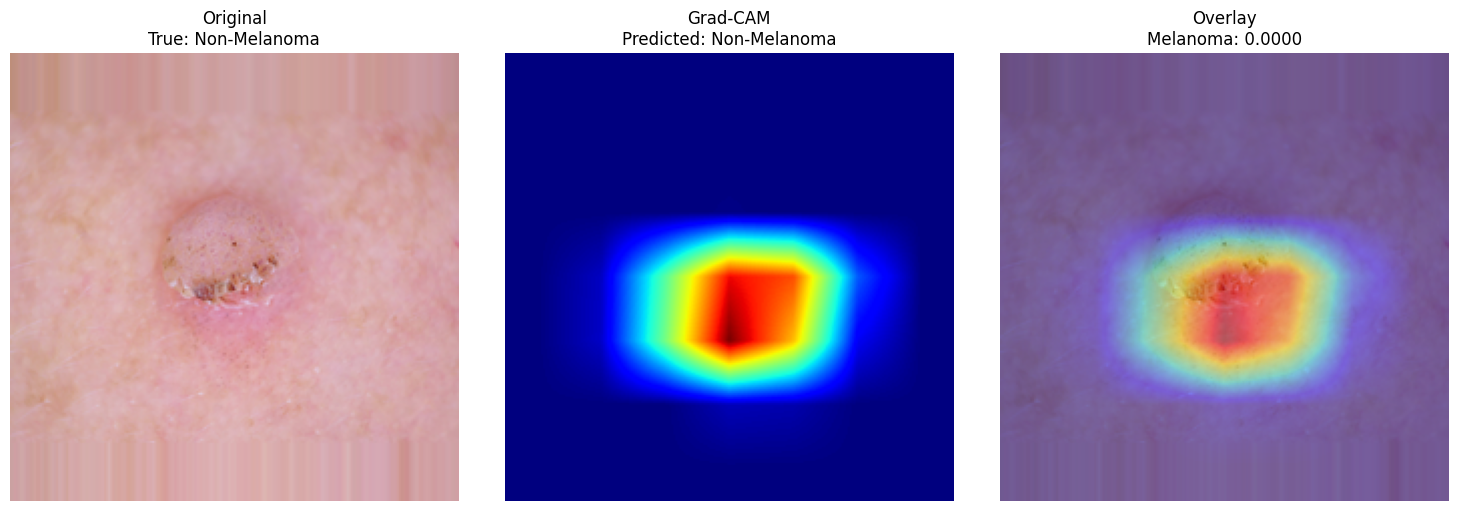

In [14]:
# Purpose: Visualize the ResNet50 Grad-CAM explanation for the fixed test image

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_array)
plt.title(
    f"Original\nTrue: {class_names[true_class]}"
)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title(
    f"Grad-CAM\nPredicted: {class_names[predicted_class]}"
)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image_array)
plt.imshow(cam, cmap="jet", alpha=0.45)
plt.title(
    f"Overlay\nMelanoma: {probabilities[1]:.4f}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
# Purpose: Build a reusable Grad-CAM engine for all five benchmark models

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(
            self._save_activations
        )

        self.backward_handle = target_layer.register_full_backward_hook(
            self._save_gradients
        )

    def _save_activations(self, module, inputs, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class=None):
        self.model.zero_grad(set_to_none=True)

        output = self.model(input_tensor)

        probabilities = F.softmax(output, dim=1)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        target_score = output[:, target_class].sum()
        target_score.backward()

        activations = self.activations
        gradients = self.gradients

        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        cam = (weights * activations).sum(dim=1)

        cam = F.relu(cam)

        cam = F.interpolate(
            cam.unsqueeze(1),
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        ).squeeze(1)

        cam_min = cam.amin(
            dim=(1, 2),
            keepdim=True
        )

        cam_max = cam.amax(
            dim=(1, 2),
            keepdim=True
        )

        cam = (cam - cam_min) / (
            cam_max - cam_min + 1e-8
        )

        return (
            cam[0].cpu().numpy(),
            probabilities[0].detach().cpu().numpy(),
            target_class
        )

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


def get_gradcam_target_layer(model_name, model):
    if model_name == "AlexNet":
        return model.features[-1]

    elif model_name == "VGG16":
        return model.features[-1]

    elif model_name == "VGG19":
        return model.features[-1]

    elif model_name == "ResNet50":
        return model.layer4[-1]

    elif model_name == "EfficientNet-B0":
        return model.features[-1]

    else:
        raise ValueError(
            f"Unsupported model: {model_name}"
        )


print("=" * 70)
print("GRAD-CAM ENGINE")
print("=" * 70)

gradcam_objects = {}

for model_name, model in xai_models.items():
    target_layer = get_gradcam_target_layer(
        model_name,
        model
    )

    gradcam_objects[model_name] = GradCAM(
        model,
        target_layer
    )

    print(
        f"{model_name:<20} "
        f"Target layer: {target_layer.__class__.__name__}"
    )

print("=" * 70)
print("Grad-CAM engine ready for all five models")
print("=" * 70)

GRAD-CAM ENGINE
AlexNet              Target layer: MaxPool2d
VGG16                Target layer: MaxPool2d
VGG19                Target layer: MaxPool2d
ResNet50             Target layer: Bottleneck
EfficientNet-B0      Target layer: Conv2dNormActivation
Grad-CAM engine ready for all five models


In [16]:
# Purpose: Correct Grad-CAM target layers to the final convolutional feature layers

import torch.nn as nn

for gradcam in gradcam_objects.values():
    gradcam.remove_hooks()

def get_correct_gradcam_target_layer(model_name, model):
    if model_name in ["AlexNet", "VGG16", "VGG19"]:
        conv_layers = [
            module
            for module in model.features
            if isinstance(module, nn.Conv2d)
        ]

        return conv_layers[-1]

    elif model_name == "ResNet50":
        return model.layer4[-1].conv3

    elif model_name == "EfficientNet-B0":
        return model.features[-1][0]

    else:
        raise ValueError(
            f"Unsupported model: {model_name}"
        )


gradcam_objects = {}

print("=" * 70)
print("CORRECTED GRAD-CAM TARGET LAYERS")
print("=" * 70)

for model_name, model in xai_models.items():
    target_layer = get_correct_gradcam_target_layer(
        model_name,
        model
    )

    gradcam_objects[model_name] = GradCAM(
        model,
        target_layer
    )

    print(
        f"{model_name:<20} "
        f"Target layer: {target_layer.__class__.__name__}"
    )

print("=" * 70)
print("Corrected Grad-CAM engine ready")
print("=" * 70)

CORRECTED GRAD-CAM TARGET LAYERS
AlexNet              Target layer: Conv2d
VGG16                Target layer: Conv2d
VGG19                Target layer: Conv2d
ResNet50             Target layer: Conv2d
EfficientNet-B0      Target layer: Conv2d
Corrected Grad-CAM engine ready


In [18]:
# Purpose: Replace the Grad-CAM engine with a PyTorch-safe implementation

class GradCAMSafe:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(
            self._forward_hook
        )

    def _forward_hook(self, module, inputs, output):
        self.activations = output.clone()

        output.register_hook(
            self._gradient_hook
        )

    def _gradient_hook(self, gradient):
        self.gradients = gradient.clone()

    def generate(self, input_tensor, target_class=None):
        self.model.zero_grad(set_to_none=True)

        output = self.model(input_tensor)

        probabilities = F.softmax(output, dim=1)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        target_score = output[:, target_class].sum()
        target_score.backward()

        activations = self.activations
        gradients = self.gradients

        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        cam = (weights * activations).sum(dim=1)

        cam = F.relu(cam)

        cam = F.interpolate(
            cam.unsqueeze(1),
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        ).squeeze(1)

        cam_min = cam.amin(
            dim=(1, 2),
            keepdim=True
        )

        cam_max = cam.amax(
            dim=(1, 2),
            keepdim=True
        )

        cam = (
            cam - cam_min
        ) / (
            cam_max - cam_min + 1e-8
        )

        return (
            cam[0].detach().cpu().numpy(),
            probabilities[0].detach().cpu().numpy(),
            target_class
        )

    def remove_hooks(self):
        self.forward_handle.remove()


gradcam_objects = {}

print("=" * 70)
print("SAFE GRAD-CAM ENGINE")
print("=" * 70)

for model_name, model in xai_models.items():

    target_layer = get_correct_gradcam_target_layer(
        model_name,
        model
    )

    gradcam_objects[model_name] = GradCAMSafe(
        model,
        target_layer
    )

    print(
        f"{model_name:<20} "
        f"Target layer: {target_layer.__class__.__name__}"
    )

print("=" * 70)
print("Safe Grad-CAM engine ready")
print("=" * 70)

SAFE GRAD-CAM ENGINE
AlexNet              Target layer: Conv2d
VGG16                Target layer: Conv2d
VGG19                Target layer: Conv2d
ResNet50             Target layer: Conv2d
EfficientNet-B0      Target layer: Conv2d
Safe Grad-CAM engine ready


In [20]:
# Purpose: Disable in-place ReLU operations to make Grad-CAM compatible with PyTorch autograd

import torch.nn as nn

for gradcam in gradcam_objects.values():
    gradcam.remove_hooks()

for model_name, model in xai_models.items():
    relu_count = 0

    for module in model.modules():
        if isinstance(module, nn.ReLU):
            if module.inplace:
                module.inplace = False
                relu_count += 1

    print(
        f"{model_name:<20} "
        f"ReLU layers changed: {relu_count}"
    )

print("=" * 70)
print("IN-PLACE RELU DISABLED FOR XAI")
print("=" * 70)
print("Model weights were not changed.")
print("No model was retrained.")
print("=" * 70)

AlexNet              ReLU layers changed: 7
VGG16                ReLU layers changed: 15
VGG19                ReLU layers changed: 18
ResNet50             ReLU layers changed: 17
EfficientNet-B0      ReLU layers changed: 0
IN-PLACE RELU DISABLED FOR XAI
Model weights were not changed.
No model was retrained.


In [21]:
# Purpose: Rebuild Grad-CAM hooks after disabling in-place ReLU operations

gradcam_objects = {}

print("=" * 70)
print("REBUILDING GRAD-CAM ENGINE")
print("=" * 70)

for model_name, model in xai_models.items():

    target_layer = get_correct_gradcam_target_layer(
        model_name,
        model
    )

    gradcam_objects[model_name] = GradCAMSafe(
        model,
        target_layer
    )

    print(
        f"{model_name:<20} "
        f"Target layer: {target_layer.__class__.__name__}"
    )

print("=" * 70)
print("Grad-CAM engine rebuilt successfully")
print("=" * 70)

REBUILDING GRAD-CAM ENGINE
AlexNet              Target layer: Conv2d
VGG16                Target layer: Conv2d
VGG19                Target layer: Conv2d
ResNet50             Target layer: Conv2d
EfficientNet-B0      Target layer: Conv2d
Grad-CAM engine rebuilt successfully


ALEXNET GRAD-CAM SANITY TEST
Test index: 0
True diagnosis: Non-Melanoma
Prediction: Non-Melanoma
Melanoma probability: 0.000046
Prediction confidence: 0.999954
CAM shape: (224, 224)
CAM range: 0.000000 - 0.999999


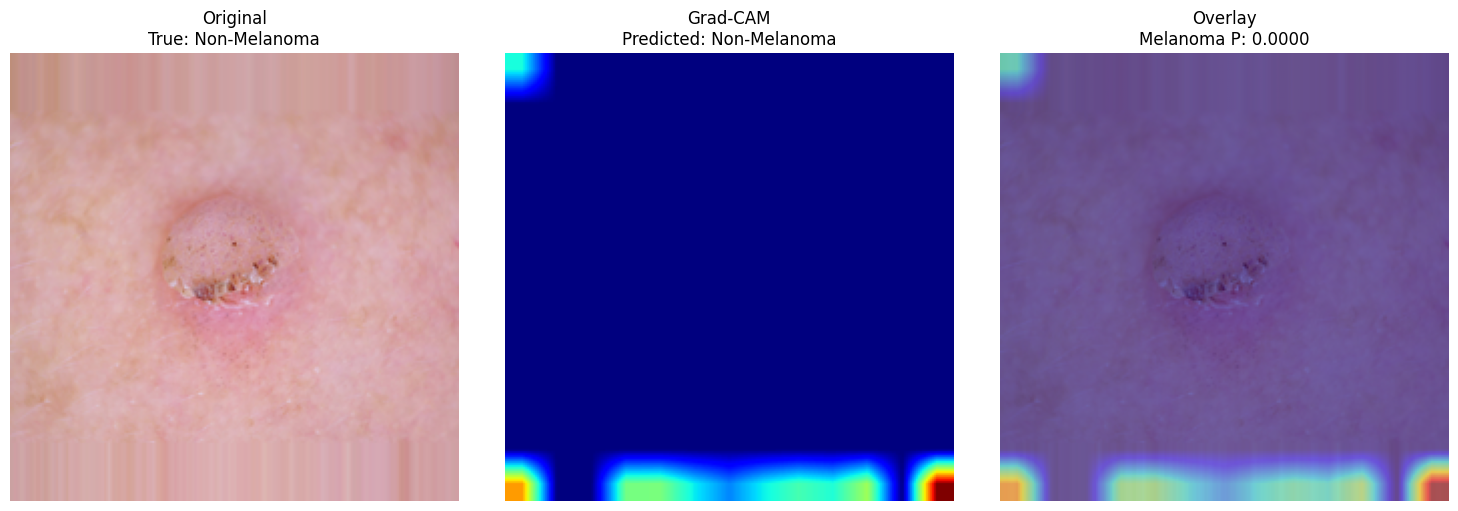

In [22]:
# Purpose: Verify Grad-CAM works correctly on AlexNet using the fixed test image

xai_index = 0

original_image = np.asarray(
    test_images[xai_index],
    dtype=np.float32
)

true_label = (
    "Melanoma"
    if test_metadata.iloc[xai_index]["dx"] == "mel"
    else "Non-Melanoma"
)

input_tensor = prepare_xai_image(
    original_image
)

cam, probabilities, predicted_class = (
    gradcam_objects["AlexNet"].generate(
        input_tensor
    )
)

predicted_label = (
    "Melanoma"
    if predicted_class == 1
    else "Non-Melanoma"
)

melanoma_probability = float(
    probabilities[1]
)

confidence = float(
    probabilities[predicted_class]
)

overlay = create_gradcam_overlay(
    original_image,
    cam
)

print("=" * 70)
print("ALEXNET GRAD-CAM SANITY TEST")
print("=" * 70)
print(f"Test index: {xai_index}")
print(f"True diagnosis: {true_label}")
print(f"Prediction: {predicted_label}")
print(f"Melanoma probability: {melanoma_probability:.6f}")
print(f"Prediction confidence: {confidence:.6f}")
print(f"CAM shape: {cam.shape}")
print(f"CAM range: {cam.min():.6f} - {cam.max():.6f}")
print("=" * 70)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(original_image)
axes[0].set_title(
    f"Original\nTrue: {true_label}"
)
axes[0].axis("off")

axes[1].imshow(
    cam,
    cmap="jet"
)
axes[1].set_title(
    f"Grad-CAM\nPredicted: {predicted_label}"
)
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title(
    f"Overlay\nMelanoma P: {melanoma_probability:.4f}"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

ALEXNET CORRECTED GRAD-CAM
Test index: 0
True diagnosis: Non-Melanoma
Prediction: Non-Melanoma
Melanoma probability: 0.000046
Confidence: 99.9954%
CAM shape: (224, 224)
CAM range: 0.0000 - 1.0000


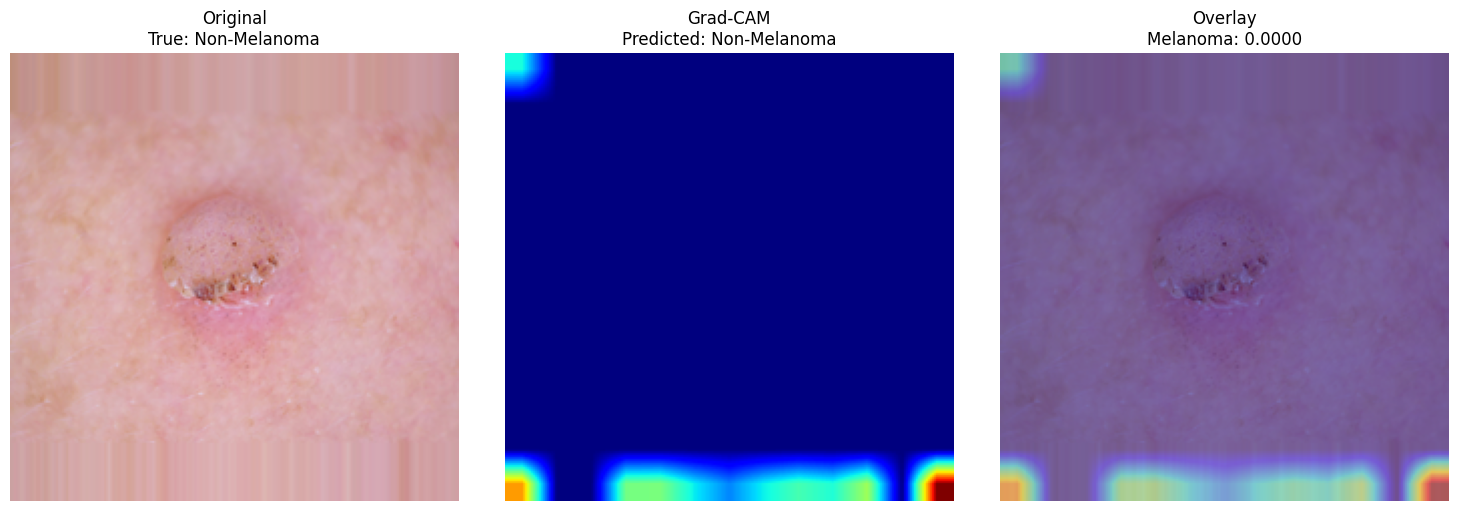

In [23]:
# Purpose: Recompute AlexNet Grad-CAM using the final convolutional layer

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image

model = xai_models["AlexNet"]
target_layer = model.features[10]

activations = None
gradients = None


def forward_hook(module, inputs, output):
    global activations
    activations = output


def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]


forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

idx = 0

image_array = np.asarray(test_images[idx], dtype=np.float32)
image_array = np.clip(image_array, 0.0, 1.0)

display_image = image_array.copy()

image_uint8 = (image_array * 255).astype(np.uint8)
pil_image = Image.fromarray(image_uint8)

xai_transform = eval_transform
input_tensor = xai_transform(pil_image).unsqueeze(0).to(device)

model.zero_grad(set_to_none=True)

output = model(input_tensor)
probabilities = F.softmax(output, dim=1)

predicted_class = int(torch.argmax(probabilities, dim=1).item())
melanoma_probability = float(probabilities[0, 1].item())

output[0, predicted_class].backward()

weights = gradients.mean(dim=(2, 3), keepdim=True)

cam = (weights * activations).sum(dim=1, keepdim=True)
cam = F.relu(cam)

cam = F.interpolate(
    cam,
    size=(224, 224),
    mode="bilinear",
    align_corners=False
)

cam = cam.squeeze().detach().cpu().numpy()

cam_min = cam.min()
cam_max = cam.max()

if cam_max > cam_min:
    cam = (cam - cam_min) / (cam_max - cam_min)
else:
    cam = np.zeros_like(cam)

true_label = "Melanoma" if test_metadata.iloc[idx]["dx"] == "mel" else "Non-Melanoma"
predicted_label = "Melanoma" if predicted_class == 1 else "Non-Melanoma"

print("=" * 70)
print("ALEXNET CORRECTED GRAD-CAM")
print("=" * 70)
print(f"Test index: {idx}")
print(f"True diagnosis: {true_label}")
print(f"Prediction: {predicted_label}")
print(f"Melanoma probability: {melanoma_probability:.6f}")
print(f"Confidence: {float(probabilities.max().item()) * 100:.4f}%")
print(f"CAM shape: {cam.shape}")
print(f"CAM range: {cam.min():.4f} - {cam.max():.4f}")
print("=" * 70)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(display_image)
plt.title(f"Original\nTrue: {true_label}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title(f"Grad-CAM\nPredicted: {predicted_label}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(display_image)
plt.imshow(cam, cmap="jet", alpha=0.45)
plt.title(f"Overlay\nMelanoma: {melanoma_probability:.4f}")
plt.axis("off")

plt.tight_layout()
plt.show()

forward_handle.remove()
backward_handle.remove()

ALEXNET CORRECTED GRAD-CAM
Test index: 0
True diagnosis: Non-Melanoma
Prediction: Non-Melanoma
Melanoma probability: 0.000046
Confidence: 99.9954%
CAM shape: (224, 224)
CAM range: 0.0000 - 1.0000


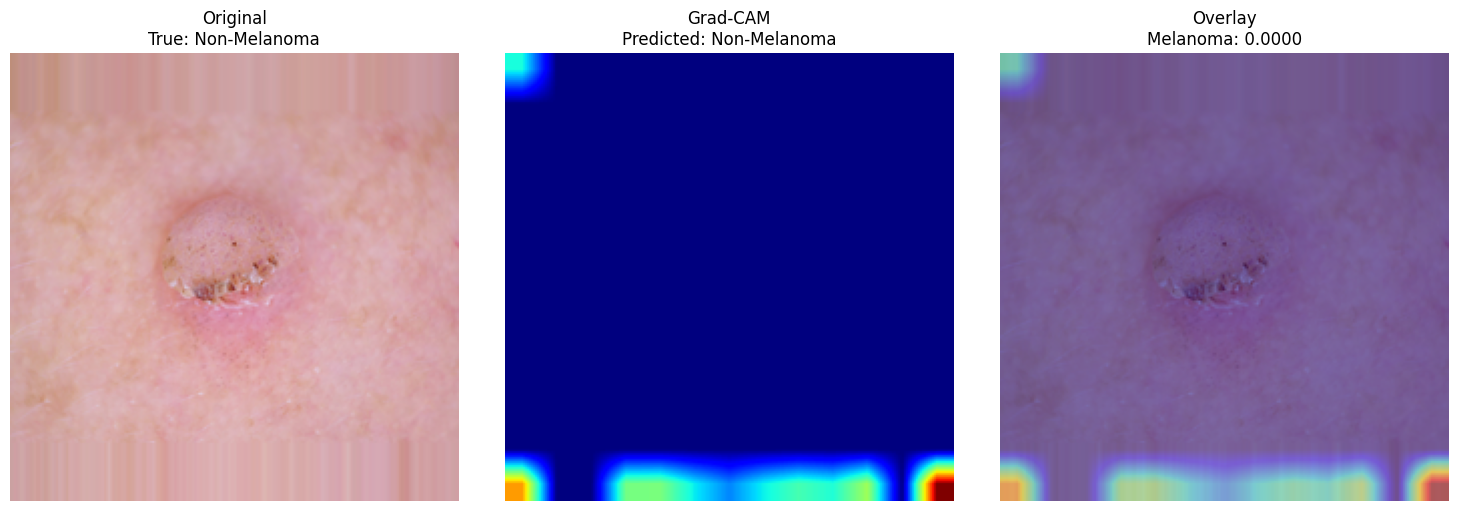

In [24]:
# Purpose: Recompute AlexNet Grad-CAM using the final convolutional layer

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image

model = xai_models["AlexNet"]
target_layer = model.features[10]

activations = None
gradients = None


def forward_hook(module, inputs, output):
    global activations
    activations = output


def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]


forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

idx = 0

image_array = np.asarray(test_images[idx], dtype=np.float32)
image_array = np.clip(image_array, 0.0, 1.0)

display_image = image_array.copy()

image_uint8 = (image_array * 255).astype(np.uint8)
pil_image = Image.fromarray(image_uint8)

xai_transform = eval_transform
input_tensor = xai_transform(pil_image).unsqueeze(0).to(device)

model.zero_grad(set_to_none=True)

output = model(input_tensor)
probabilities = F.softmax(output, dim=1)

predicted_class = int(torch.argmax(probabilities, dim=1).item())
melanoma_probability = float(probabilities[0, 1].item())

output[0, predicted_class].backward()

weights = gradients.mean(dim=(2, 3), keepdim=True)

cam = (weights * activations).sum(dim=1, keepdim=True)
cam = F.relu(cam)

cam = F.interpolate(
    cam,
    size=(224, 224),
    mode="bilinear",
    align_corners=False
)

cam = cam.squeeze().detach().cpu().numpy()

cam_min = cam.min()
cam_max = cam.max()

if cam_max > cam_min:
    cam = (cam - cam_min) / (cam_max - cam_min)
else:
    cam = np.zeros_like(cam)

true_label = "Melanoma" if test_metadata.iloc[idx]["dx"] == "mel" else "Non-Melanoma"
predicted_label = "Melanoma" if predicted_class == 1 else "Non-Melanoma"

print("=" * 70)
print("ALEXNET CORRECTED GRAD-CAM")
print("=" * 70)
print(f"Test index: {idx}")
print(f"True diagnosis: {true_label}")
print(f"Prediction: {predicted_label}")
print(f"Melanoma probability: {melanoma_probability:.6f}")
print(f"Confidence: {float(probabilities.max().item()) * 100:.4f}%")
print(f"CAM shape: {cam.shape}")
print(f"CAM range: {cam.min():.4f} - {cam.max():.4f}")
print("=" * 70)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(display_image)
plt.title(f"Original\nTrue: {true_label}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title(f"Grad-CAM\nPredicted: {predicted_label}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(display_image)
plt.imshow(cam, cmap="jet", alpha=0.45)
plt.title(f"Overlay\nMelanoma: {melanoma_probability:.4f}")
plt.axis("off")

plt.tight_layout()
plt.show()

forward_handle.remove()
backward_handle.remove()

In [25]:
# Purpose: Define a standardized Grad-CAM function for all five benchmark models

def get_gradcam_target_layer(model_name, model):
    if model_name == "AlexNet":
        return model.features[10]

    elif model_name == "VGG16":
        return model.features[28]

    elif model_name == "VGG19":
        return model.features[34]

    elif model_name == "ResNet50":
        return model.layer4[-1]

    elif model_name == "EfficientNet-B0":
        return model.features[-1]

    else:
        raise ValueError(f"Unsupported model: {model_name}")


def generate_gradcam(model_name, model, image_array, target_class=None):
    target_layer = get_gradcam_target_layer(model_name, model)

    activations = []
    gradients = []

    def forward_hook(module, inputs, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)

    try:
        image_array = np.asarray(image_array, dtype=np.float32)
        image_array = np.clip(image_array, 0.0, 1.0)

        image_uint8 = (image_array * 255).astype(np.uint8)
        pil_image = Image.fromarray(image_uint8)

        input_tensor = eval_transform(pil_image).unsqueeze(0).to(device)

        model.zero_grad(set_to_none=True)

        output = model(input_tensor)
        probabilities = F.softmax(output, dim=1)

        predicted_class = int(torch.argmax(probabilities, dim=1).item())

        if target_class is None:
            target_class = predicted_class

        output[0, target_class].backward()

        activation = activations[0]
        gradient = gradients[0]

        weights = gradient.mean(
            dim=(2, 3),
            keepdim=True
        )

        cam = (weights * activation).sum(
            dim=1,
            keepdim=True
        )

        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze().detach().cpu().numpy()

        cam_min = cam.min()
        cam_max = cam.max()

        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = np.zeros_like(cam)

        return {
            "cam": cam,
            "probabilities": probabilities[0].detach().cpu().numpy(),
            "predicted_class": predicted_class,
            "target_class": target_class
        }

    finally:
        forward_handle.remove()
        backward_handle.remove()


print("=" * 70)
print("STANDARDIZED GRAD-CAM FUNCTION")
print("=" * 70)

for model_name in xai_models:
    target_layer = get_gradcam_target_layer(
        model_name,
        xai_models[model_name]
    )
    print(
        f"{model_name:<20} Target layer: {target_layer.__class__.__name__}"
    )

print("=" * 70)
print("Grad-CAM function ready for all five models")
print("=" * 70)

STANDARDIZED GRAD-CAM FUNCTION
AlexNet              Target layer: Conv2d
VGG16                Target layer: Conv2d
VGG19                Target layer: Conv2d
ResNet50             Target layer: Bottleneck
EfficientNet-B0      Target layer: Conv2dNormActivation
Grad-CAM function ready for all five models


In [26]:
# Purpose: Test standardized Grad-CAM on the same HAM10000 test image for all five models

idx = 0

image_array = np.asarray(test_images[idx], dtype=np.float32)
true_label = "Melanoma" if test_metadata.iloc[idx]["dx"] == "mel" else "Non-Melanoma"

print("=" * 70)
print("FIVE-MODEL GRAD-CAM SANITY CHECK")
print("=" * 70)
print(f"Test index: {idx}")
print(f"True diagnosis: {true_label}")
print()

gradcam_sanity_results = {}

for model_name, model in xai_models.items():
    result = generate_gradcam(
        model_name,
        model,
        image_array
    )

    predicted_class = result["predicted_class"]
    predicted_label = (
        "Melanoma"
        if predicted_class == 1
        else "Non-Melanoma"
    )

    melanoma_probability = float(
        result["probabilities"][1]
    )

    gradcam_sanity_results[model_name] = result

    print(
        f"{model_name:<20} "
        f"Prediction: {predicted_label:<15} "
        f"Melanoma probability: {melanoma_probability:.6f} "
        f"| CAM: {result['cam'].shape}"
    )

print()
print("=" * 70)
print("Grad-CAM sanity check completed")
print("=" * 70)

FIVE-MODEL GRAD-CAM SANITY CHECK
Test index: 0
True diagnosis: Non-Melanoma

AlexNet              Prediction: Non-Melanoma    Melanoma probability: 0.000046 | CAM: (224, 224)
VGG16                Prediction: Non-Melanoma    Melanoma probability: 0.001164 | CAM: (224, 224)
VGG19                Prediction: Non-Melanoma    Melanoma probability: 0.063602 | CAM: (224, 224)
ResNet50             Prediction: Non-Melanoma    Melanoma probability: 0.000008 | CAM: (224, 224)
EfficientNet-B0      Prediction: Non-Melanoma    Melanoma probability: 0.000023 | CAM: (224, 224)

Grad-CAM sanity check completed


GRAD-CAM VISUAL COMPARISON
Test index: 0
True diagnosis: Non-Melanoma


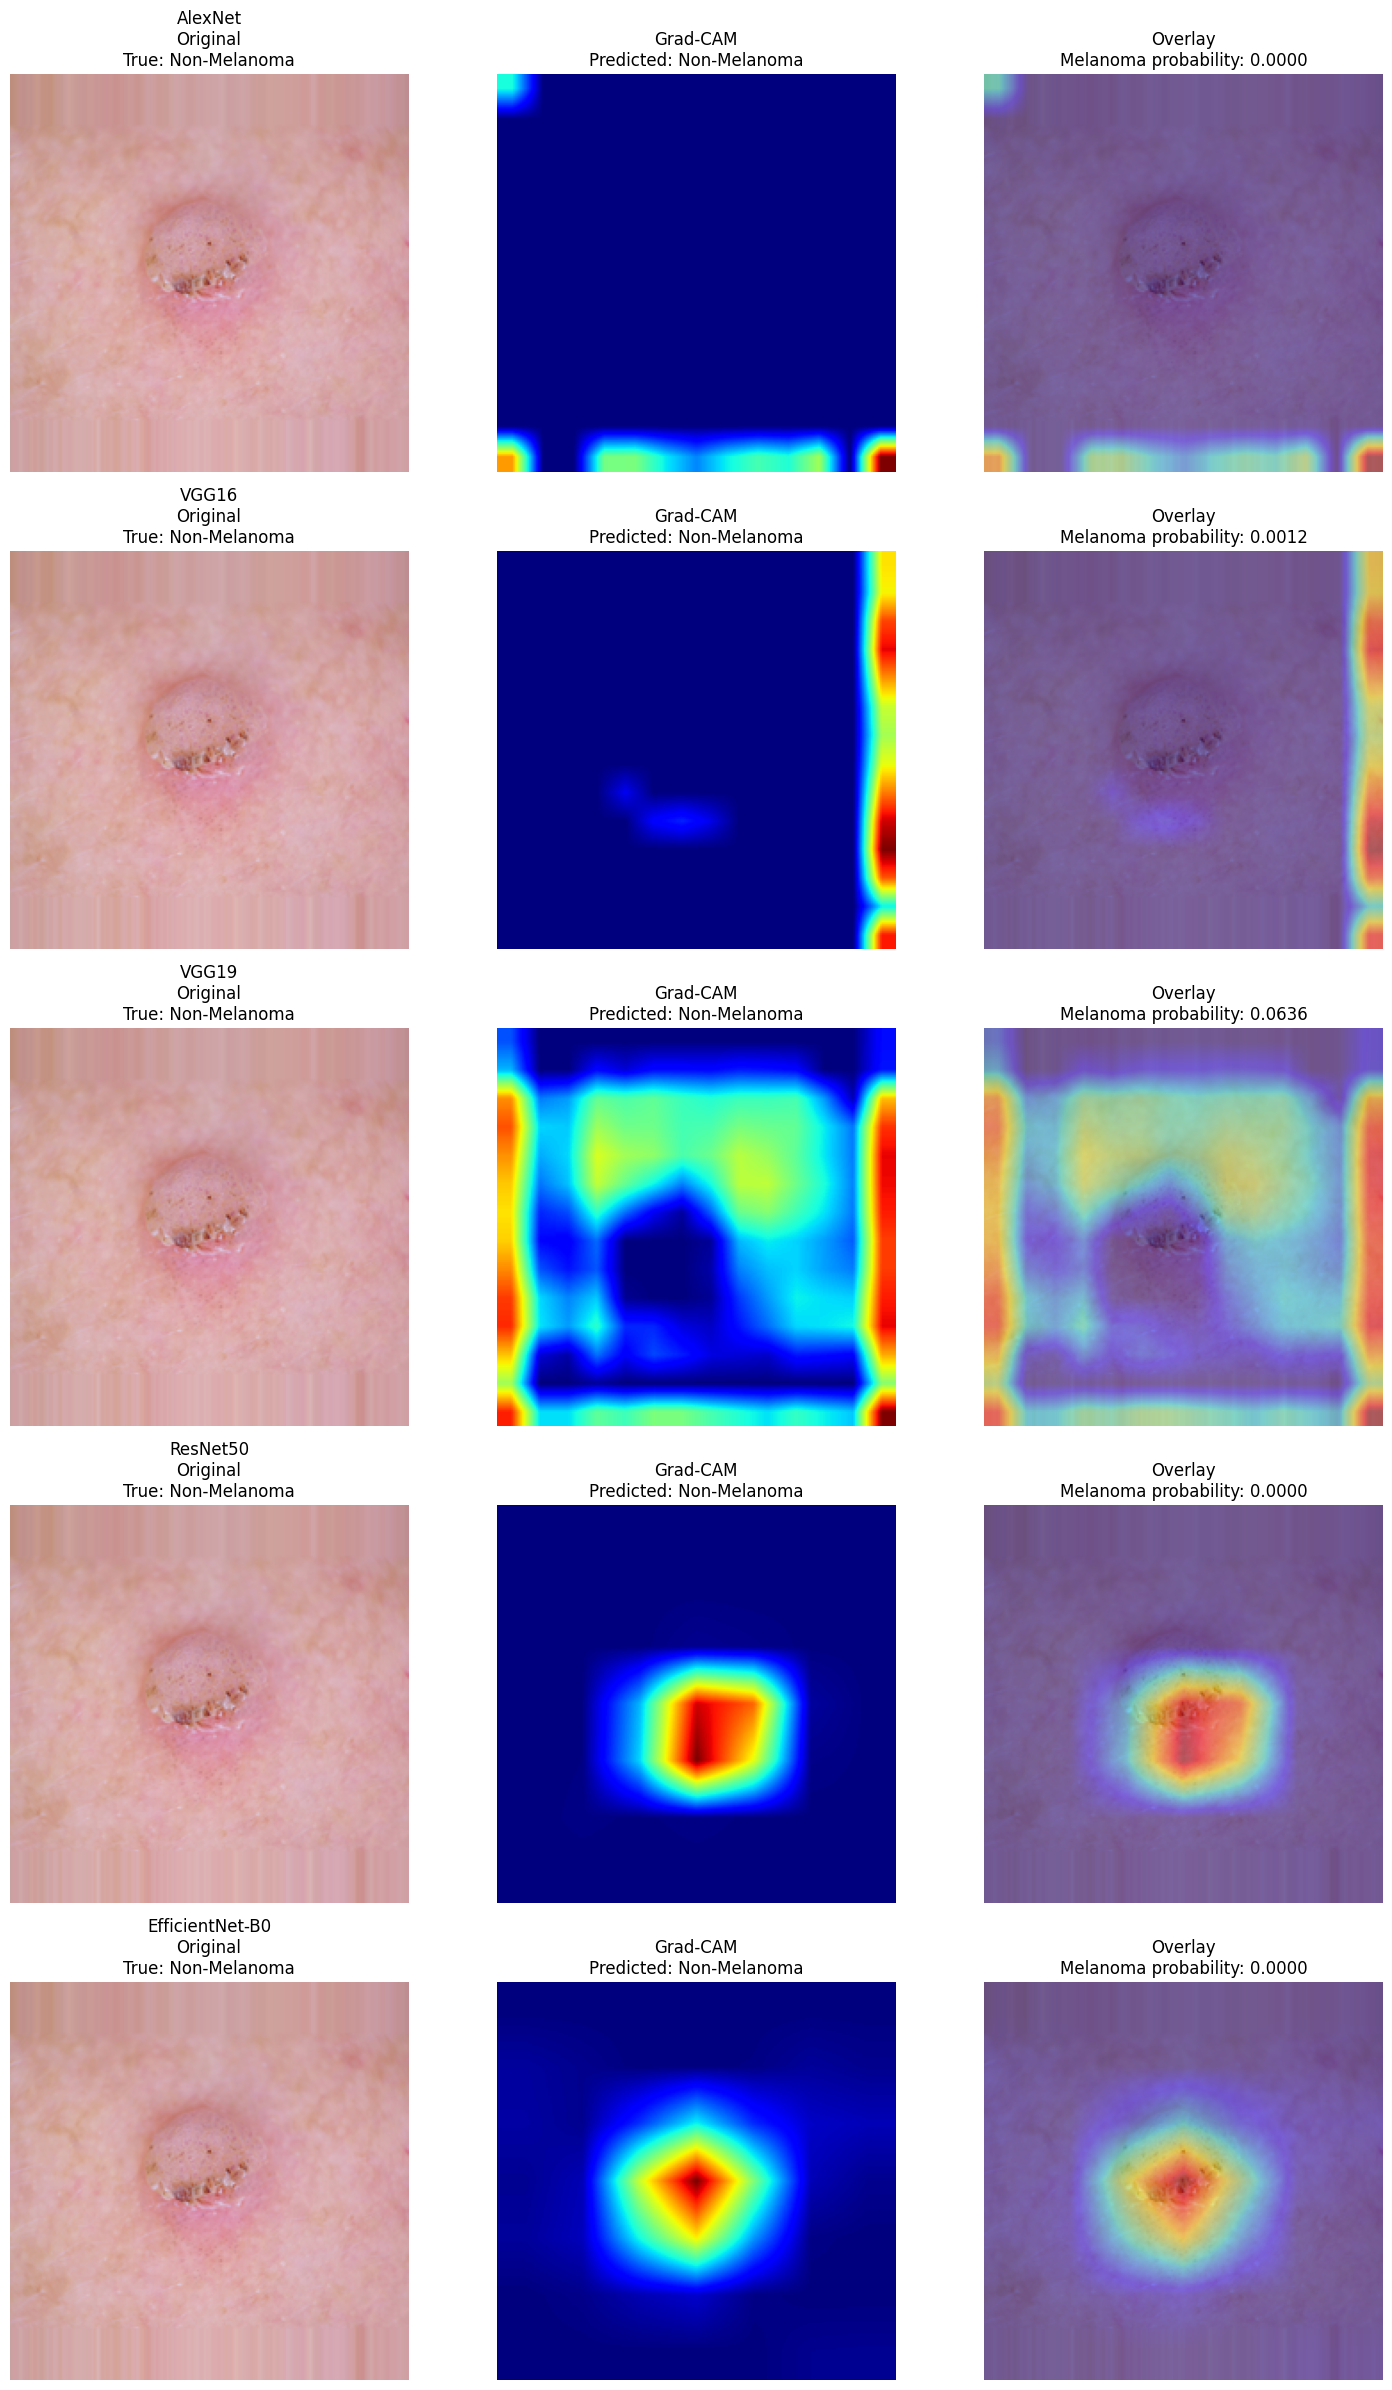


VISUAL COMPARISON COMPLETED


In [27]:
# Purpose: Visually compare Grad-CAM explanations from all five benchmark models on one fixed test image

idx = 0

image_array = np.asarray(test_images[idx], dtype=np.float32)
image_array = np.clip(image_array, 0.0, 1.0)

true_label = (
    "Melanoma"
    if test_metadata.iloc[idx]["dx"] == "mel"
    else "Non-Melanoma"
)

print("=" * 70)
print("GRAD-CAM VISUAL COMPARISON")
print("=" * 70)
print(f"Test index: {idx}")
print(f"True diagnosis: {true_label}")
print("=" * 70)

fig, axes = plt.subplots(
    5,
    3,
    figsize=(15, 24)
)

for row, (model_name, model) in enumerate(xai_models.items()):

    result = generate_gradcam(
        model_name,
        model,
        image_array
    )

    cam = result["cam"]
    predicted_class = result["predicted_class"]
    predicted_label = (
        "Melanoma"
        if predicted_class == 1
        else "Non-Melanoma"
    )

    melanoma_probability = float(
        result["probabilities"][1]
    )

    axes[row, 0].imshow(image_array)
    axes[row, 0].set_title(
        f"{model_name}\nOriginal\nTrue: {true_label}"
    )
    axes[row, 0].axis("off")

    axes[row, 1].imshow(cam, cmap="jet")
    axes[row, 1].set_title(
        f"Grad-CAM\nPredicted: {predicted_label}"
    )
    axes[row, 1].axis("off")

    axes[row, 2].imshow(image_array)
    axes[row, 2].imshow(
        cam,
        cmap="jet",
        alpha=0.45
    )
    axes[row, 2].set_title(
        f"Overlay\nMelanoma probability: {melanoma_probability:.4f}"
    )
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

print()
print("=" * 70)
print("VISUAL COMPARISON COMPLETED")
print("=" * 70)

In [28]:
# Purpose: Generate and save the complete 5-model × 5-image Grad-CAM experiment

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

GRADCAM_DIR = Path("/kaggle/working/LAMNet_HAM10000/GradCAM")
GRADCAM_DIR.mkdir(parents=True, exist_ok=True)

GRADCAM_IMAGE_DIR = GRADCAM_DIR / "visualizations"
GRADCAM_CAM_DIR = GRADCAM_DIR / "cams"

GRADCAM_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
GRADCAM_CAM_DIR.mkdir(parents=True, exist_ok=True)

gradcam_records = []

print("=" * 70)
print("FULL GRAD-CAM EXPERIMENT")
print("=" * 70)
print(f"Models: {len(xai_models)}")
print(f"Fixed images: {len(XAI_SAMPLE_INDICES)}")
print(f"Total explanations: {len(xai_models) * len(XAI_SAMPLE_INDICES)}")
print()

for model_name, model in xai_models.items():

    print(f"Processing {model_name}...")

    for idx in XAI_SAMPLE_INDICES:

        image_array = np.asarray(
            test_images[idx],
            dtype=np.float32
        )

        image_array = np.clip(
            image_array,
            0.0,
            1.0
        )

        true_label = (
            "Melanoma"
            if test_metadata.iloc[idx]["dx"] == "mel"
            else "Non-Melanoma"
        )

        result = generate_gradcam(
            model_name,
            model,
            image_array
        )

        cam = result["cam"]

        predicted_class = result["predicted_class"]

        predicted_label = (
            "Melanoma"
            if predicted_class == 1
            else "Non-Melanoma"
        )

        probabilities = result["probabilities"]

        melanoma_probability = float(
            probabilities[1]
        )

        confidence = float(
            probabilities.max()
        )

        correct = (
            predicted_class
            == (1 if true_label == "Melanoma" else 0)
        )

        base_name = (
            f"{model_name.replace('-', '')}"
            f"_index_{idx}"
        )

        cam_path = (
            GRADCAM_CAM_DIR
            / f"{base_name}_cam.npy"
        )

        visualization_path = (
            GRADCAM_IMAGE_DIR
            / f"{base_name}.png"
        )

        np.save(
            cam_path,
            cam
        )

        fig, axes = plt.subplots(
            1,
            3,
            figsize=(15, 5)
        )

        axes[0].imshow(image_array)
        axes[0].set_title(
            f"Original\n"
            f"True: {true_label}"
        )
        axes[0].axis("off")

        axes[1].imshow(
            cam,
            cmap="jet"
        )
        axes[1].set_title(
            f"Grad-CAM\n"
            f"Predicted: {predicted_label}"
        )
        axes[1].axis("off")

        axes[2].imshow(image_array)
        axes[2].imshow(
            cam,
            cmap="jet",
            alpha=0.45
        )
        axes[2].set_title(
            f"Overlay\n"
            f"Melanoma probability: "
            f"{melanoma_probability:.4f}"
        )
        axes[2].axis("off")

        plt.tight_layout()
        plt.savefig(
            visualization_path,
            dpi=200,
            bbox_inches="tight"
        )
        plt.close(fig)

        gradcam_records.append({
            "model": model_name,
            "test_index": int(idx),
            "true_label": true_label,
            "predicted_label": predicted_label,
            "true_class": int(
                1 if true_label == "Melanoma" else 0
            ),
            "predicted_class": int(predicted_class),
            "melanoma_probability": melanoma_probability,
            "non_melanoma_probability": float(
                probabilities[0]
            ),
            "confidence": confidence,
            "correct_prediction": bool(correct),
            "cam_min": float(cam.min()),
            "cam_max": float(cam.max()),
            "cam_mean": float(cam.mean()),
            "cam_std": float(cam.std()),
            "cam_file": str(cam_path),
            "visualization_file": str(
                visualization_path
            )
        })

    print(f"  Completed: {len(XAI_SAMPLE_INDICES)} images")

gradcam_results_df = pd.DataFrame(
    gradcam_records
)

csv_path = (
    GRADCAM_DIR
    / "GradCAM_5Models_5Images_Results.csv"
)

json_path = (
    GRADCAM_DIR
    / "GradCAM_5Models_5Images_Results.json"
)

gradcam_results_df.to_csv(
    csv_path,
    index=False
)

with open(json_path, "w") as f:
    json.dump(
        gradcam_records,
        f,
        indent=2
    )

print()
print("=" * 70)
print("FULL GRAD-CAM EXPERIMENT COMPLETED")
print("=" * 70)
print(
    f"Total explanations saved: "
    f"{len(gradcam_results_df)}"
)
print(
    f"CSV: {csv_path}"
)
print(
    f"JSON: {json_path}"
)
print(
    f"Visualizations: {GRADCAM_IMAGE_DIR}"
)
print(
    f"CAM arrays: {GRADCAM_CAM_DIR}"
)
print("=" * 70)

FULL GRAD-CAM EXPERIMENT
Models: 5
Fixed images: 5
Total explanations: 25

Processing AlexNet...
  Completed: 5 images
Processing VGG16...
  Completed: 5 images
Processing VGG19...
  Completed: 5 images
Processing ResNet50...
  Completed: 5 images
Processing EfficientNet-B0...
  Completed: 5 images

FULL GRAD-CAM EXPERIMENT COMPLETED
Total explanations saved: 25
CSV: /kaggle/working/LAMNet_HAM10000/GradCAM/GradCAM_5Models_5Images_Results.csv
JSON: /kaggle/working/LAMNet_HAM10000/GradCAM/GradCAM_5Models_5Images_Results.json
Visualizations: /kaggle/working/LAMNet_HAM10000/GradCAM/visualizations
CAM arrays: /kaggle/working/LAMNet_HAM10000/GradCAM/cams


In [29]:
# Purpose: Check whether the required LIME dependencies are available

import sys
import numpy as np

print("=" * 70)
print("LIME DEPENDENCY CHECK")
print("=" * 70)

print(f"Python version: {sys.version.split()[0]}")

try:
    import lime
    from lime import lime_image
    print(f"LIME: Available")
    print(f"LIME version: {getattr(lime, '__version__', 'version not reported')}")
except ImportError:
    print("LIME: Not installed")

try:
    import skimage
    print(f"scikit-image: Available")
    print(f"scikit-image version: {skimage.__version__}")
except ImportError:
    print("scikit-image: Not installed")

print(f"NumPy version: {np.__version__}")

print("=" * 70)
print("LIME DEPENDENCY CHECK COMPLETED")
print("=" * 70)

LIME DEPENDENCY CHECK
Python version: 3.12.13
LIME: Available
LIME version: version not reported
scikit-image: Available
scikit-image version: 0.25.2
NumPy version: 2.0.2
LIME DEPENDENCY CHECK COMPLETED


In [30]:
# Purpose: Define a standardized model prediction wrapper for LIME

from lime import lime_image


def lime_predict(model, images):
    batch_tensors = []

    for image in images:
        image = np.asarray(image, dtype=np.float32)
        image = np.clip(image, 0.0, 1.0)

        image_uint8 = (image * 255).astype(np.uint8)
        pil_image = Image.fromarray(image_uint8)

        tensor = eval_transform(pil_image)
        batch_tensors.append(tensor)

    batch = torch.stack(batch_tensors).to(device)

    with torch.no_grad():
        outputs = model(batch)
        probabilities = F.softmax(outputs, dim=1)

    return probabilities.cpu().numpy()


lime_explainer = lime_image.LimeImageExplainer(
    random_state=42
)

print("=" * 70)
print("LIME PREDICTION WRAPPER")
print("=" * 70)
print("Prediction wrapper: Ready")
print("LIME explainer: Ready")
print("Random state: 42")
print("=" * 70)

LIME PREDICTION WRAPPER
Prediction wrapper: Ready
LIME explainer: Ready
Random state: 42


In [32]:
# Purpose: Remove stale Grad-CAM hooks from the ResNet50 model before LIME analysis

model = xai_models["ResNet50"]

removed_hooks = 0

for module in model.modules():
    if hasattr(module, "_forward_hooks"):
        hook_count = len(module._forward_hooks)
        if hook_count > 0:
            module._forward_hooks.clear()
            removed_hooks += hook_count

    if hasattr(module, "_backward_hooks"):
        hook_count = len(module._backward_hooks)
        if hook_count > 0:
            module._backward_hooks.clear()
            removed_hooks += hook_count

print("=" * 70)
print("RESNET50 GRAD-CAM HOOK CLEANUP")
print("=" * 70)
print(f"Hooks removed: {removed_hooks}")
print("ResNet50 is ready for LIME inference")
print("=" * 70)

RESNET50 GRAD-CAM HOOK CLEANUP
Hooks removed: 5
ResNet50 is ready for LIME inference


In [33]:
# Purpose: Verify that LIME can generate an explanation for ResNet50 after hook cleanup

idx = 0
model_name = "ResNet50"

model = xai_models[model_name]

image_array = np.asarray(
    test_images[idx],
    dtype=np.float32
)

image_array = np.clip(
    image_array,
    0.0,
    1.0
)

true_label = (
    "Melanoma"
    if test_metadata.iloc[idx]["dx"] == "mel"
    else "Non-Melanoma"
)

print("=" * 70)
print("LIME SINGLE-IMAGE SANITY TEST")
print("=" * 70)
print(f"Model: {model_name}")
print(f"Test index: {idx}")
print(f"True diagnosis: {true_label}")
print()
print("Generating LIME explanation...")
print("This may take a little time.")
print()

explanation = lime_explainer.explain_instance(
    image_array,
    classifier_fn=lambda images: lime_predict(
        model,
        images
    ),
    top_labels=2,
    hide_color=0,
    num_samples=500
)

prediction = lime_predict(
    model,
    [image_array]
)[0]

predicted_class = int(
    np.argmax(prediction)
)

predicted_label = (
    "Melanoma"
    if predicted_class == 1
    else "Non-Melanoma"
)

print("=" * 70)
print("LIME SANITY TEST RESULT")
print("=" * 70)
print(f"Model: {model_name}")
print(f"True diagnosis: {true_label}")
print(f"Prediction: {predicted_label}")
print(f"Non-Melanoma probability: {prediction[0]:.6f}")
print(f"Melanoma probability: {prediction[1]:.6f}")
print(f"Available explanation labels: {explanation.top_labels}")
print("=" * 70)

LIME SINGLE-IMAGE SANITY TEST
Model: ResNet50
Test index: 0
True diagnosis: Non-Melanoma

Generating LIME explanation...
This may take a little time.



  0%|          | 0/500 [00:00<?, ?it/s]

LIME SANITY TEST RESULT
Model: ResNet50
True diagnosis: Non-Melanoma
Prediction: Non-Melanoma
Non-Melanoma probability: 0.999992
Melanoma probability: 0.000008
Available explanation labels: [np.int64(0), np.int64(1)]


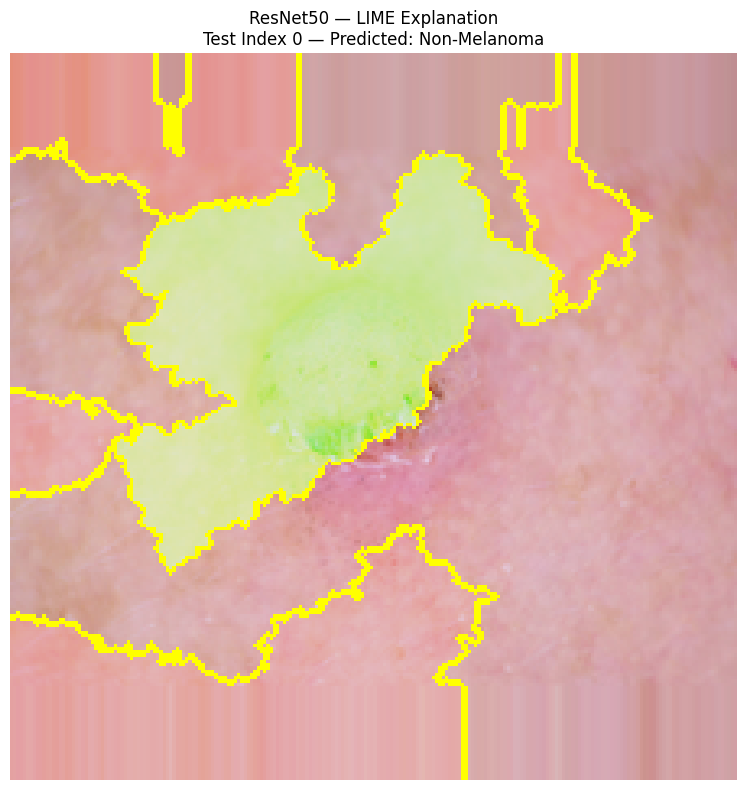

In [34]:
# Purpose: Visualize the ResNet50 LIME explanation for the fixed sanity-test image

from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt

label_to_explain = predicted_class

lime_image_positive, lime_mask = explanation.get_image_and_mask(
    label=label_to_explain,
    positive_only=False,
    num_features=10,
    hide_rest=False
)

lime_image_positive = np.clip(
    lime_image_positive,
    0.0,
    1.0
)

plt.figure(figsize=(8, 8))

plt.imshow(
    mark_boundaries(
        lime_image_positive,
        lime_mask
    )
)

plt.title(
    f"{model_name} — LIME Explanation\n"
    f"Test Index {idx} — Predicted: {predicted_label}"
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [35]:
# Purpose: Verify the LIME dependencies required for standardized XAI analysis

import importlib.util

lime_available = importlib.util.find_spec("lime") is not None
skimage_available = importlib.util.find_spec("skimage") is not None

print("=" * 70)
print("LIME DEPENDENCY CHECK")
print("=" * 70)
print(f"LIME package available: {lime_available}")
print(f"scikit-image available: {skimage_available}")

if lime_available and skimage_available:
    from lime import lime_image
    print("LIME dependencies are ready")
else:
    print("One or more LIME dependencies are missing")

print("=" * 70)

LIME DEPENDENCY CHECK
LIME package available: True
scikit-image available: True
LIME dependencies are ready


In [36]:
# Purpose: Define a standardized LIME prediction and explanation function for all five models

from lime import lime_image


def lime_predict(model, images):
    batch_tensors = []

    for image in images:
        image = np.asarray(image, dtype=np.float32)
        image = np.clip(image, 0.0, 1.0)

        image_uint8 = (image * 255).astype(np.uint8)
        pil_image = Image.fromarray(image_uint8)

        tensor = eval_transform(pil_image)
        batch_tensors.append(tensor)

    batch = torch.stack(batch_tensors).to(device)

    with torch.no_grad():
        outputs = model(batch)
        probabilities = F.softmax(outputs, dim=1)

    return probabilities.cpu().numpy()


lime_explainer = lime_image.LimeImageExplainer(
    random_state=42
)

print("=" * 70)
print("STANDARDIZED LIME FUNCTION")
print("=" * 70)
print("Prediction function: Ready")
print("LIME explainer: Ready")
print("Random state: 42")
print("Number of classes: 2")
print("Input size: 224 x 224")
print("=" * 70)

STANDARDIZED LIME FUNCTION
Prediction function: Ready
LIME explainer: Ready
Random state: 42
Number of classes: 2
Input size: 224 x 224


  0%|          | 0/1000 [00:00<?, ?it/s]

RESNET50 LIME SANITY TEST
Test index: 0
True diagnosis: Non-Melanoma
Prediction: Non-Melanoma
Melanoma probability: 0.000008
Explanation labels: [np.int64(0), np.int64(1)]

Top LIME feature contributions:

Class: 0
Superpixel 40    Contribution: -0.042254
Superpixel 2     Contribution: -0.034478
Superpixel 17    Contribution: -0.031746
Superpixel 13    Contribution: +0.031657
Superpixel 15    Contribution: +0.029707
Superpixel 10    Contribution: -0.026631
Superpixel 4     Contribution: -0.020772
Superpixel 33    Contribution: -0.019827
Superpixel 25    Contribution: +0.018961
Superpixel 21    Contribution: +0.018813

Class: 1
Superpixel 40    Contribution: +0.042254
Superpixel 2     Contribution: +0.034478
Superpixel 17    Contribution: +0.031746
Superpixel 13    Contribution: -0.031657
Superpixel 15    Contribution: -0.029707
Superpixel 10    Contribution: +0.026631
Superpixel 4     Contribution: +0.020772
Superpixel 33    Contribution: +0.019827
Superpixel 25    Contribution: -0.018

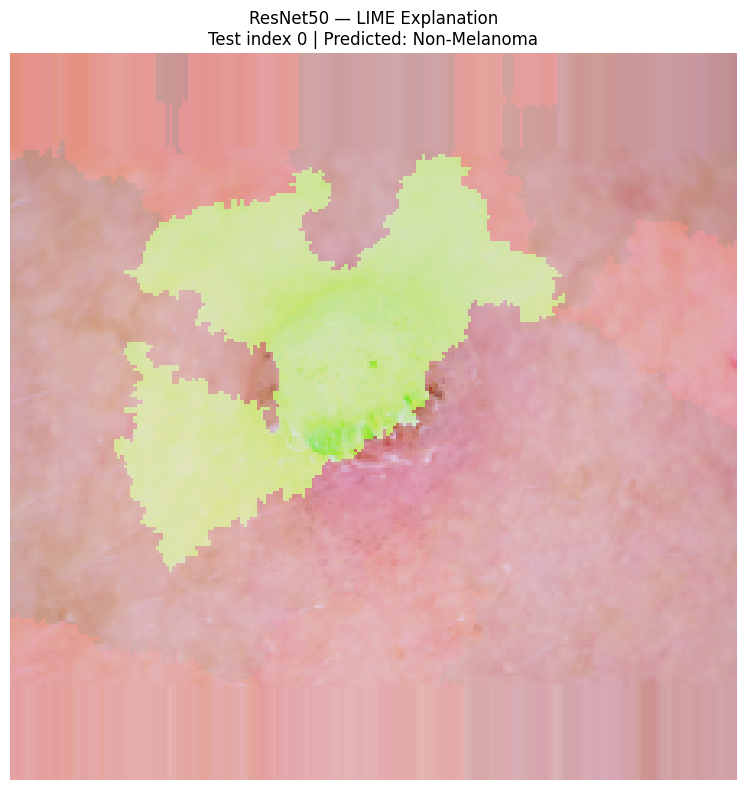

In [37]:
# Purpose: Validate the standardized LIME explanation on ResNet50 using the fixed test image

idx = 0
model_name = "ResNet50"
model = xai_models[model_name]

image_array = np.asarray(
    test_images[idx],
    dtype=np.float32
)

image_array = np.clip(
    image_array,
    0.0,
    1.0
)

true_label = (
    "Melanoma"
    if test_metadata.iloc[idx]["dx"] == "mel"
    else "Non-Melanoma"
)

explanation = lime_explainer.explain_instance(
    image_array,
    classifier_fn=lambda images: lime_predict(
        model,
        images
    ),
    top_labels=2,
    hide_color=0,
    num_samples=1000
)

with torch.no_grad():
    prediction_probabilities = lime_predict(
        model,
        [image_array]
    )[0]

predicted_class = int(
    np.argmax(prediction_probabilities)
)

predicted_label = (
    "Melanoma"
    if predicted_class == 1
    else "Non-Melanoma"
)

melanoma_probability = float(
    prediction_probabilities[1]
)

print("=" * 70)
print("RESNET50 LIME SANITY TEST")
print("=" * 70)
print(f"Test index: {idx}")
print(f"True diagnosis: {true_label}")
print(f"Prediction: {predicted_label}")
print(f"Melanoma probability: {melanoma_probability:.6f}")
print(f"Explanation labels: {explanation.top_labels}")
print("=" * 70)

print("\nTop LIME feature contributions:")

for label in explanation.top_labels:
    contributions = explanation.local_exp[label]

    print(f"\nClass: {label}")

    for feature_id, weight in contributions[:10]:
        print(
            f"Superpixel {feature_id:<5} "
            f"Contribution: {weight:+.6f}"
        )

print("=" * 70)

temp, mask = explanation.get_image_and_mask(
    predicted_class,
    positive_only=False,
    num_features=10,
    hide_rest=False
)

plt.figure(figsize=(8, 8))

plt.imshow(temp)
plt.title(
    f"{model_name} — LIME Explanation\n"
    f"Test index {idx} | Predicted: {predicted_label}"
)
plt.axis("off")
plt.tight_layout()
plt.show()

In [38]:
# Purpose: Define a standardized LIME explanation procedure for all five benchmark models

from lime import lime_image
from skimage.segmentation import mark_boundaries

LIME_NUM_SAMPLES = 1000
LIME_NUM_FEATURES = 10
LIME_BATCH_SIZE = 32

lime_explainer = lime_image.LimeImageExplainer(
    random_state=42
)


def lime_predict(model, images):
    predictions = []

    for start in range(0, len(images), LIME_BATCH_SIZE):
        batch_images = images[
            start:start + LIME_BATCH_SIZE
        ]

        batch_tensors = []

        for image in batch_images:
            image = np.asarray(
                image,
                dtype=np.float32
            )
            image = np.clip(
                image,
                0.0,
                1.0
            )

            image_uint8 = (
                image * 255
            ).astype(np.uint8)

            pil_image = Image.fromarray(
                image_uint8
            )

            tensor = eval_transform(
                pil_image
            )

            batch_tensors.append(tensor)

        batch_tensor = torch.stack(
            batch_tensors
        ).to(device)

        with torch.no_grad():
            output = model(
                batch_tensor
            )

            probabilities = F.softmax(
                output,
                dim=1
            )

        predictions.append(
            probabilities.cpu().numpy()
        )

    return np.concatenate(
        predictions,
        axis=0
    )


def generate_lime_explanation(
    model_name,
    model,
    image_array
):
    image_array = np.asarray(
        image_array,
        dtype=np.float32
    )

    image_array = np.clip(
        image_array,
        0.0,
        1.0
    )

    explanation = lime_explainer.explain_instance(
        image_array,
        lambda images: lime_predict(
            model,
            images
        ),
        top_labels=2,
        hide_color=0,
        num_samples=LIME_NUM_SAMPLES
    )

    image_uint8 = (
        image_array * 255
    ).astype(np.uint8)

    image_for_display = (
        image_uint8 / 255.0
    )

    probabilities = lime_predict(
        model,
        np.expand_dims(
            image_array,
            axis=0
        )
    )[0]

    predicted_class = int(
        np.argmax(probabilities)
    )

    predicted_label = (
        "Melanoma"
        if predicted_class == 1
        else "Non-Melanoma"
    )

    positive_image, positive_mask = (
        explanation.get_image_and_mask(
            predicted_class,
            positive_only=False,
            num_features=LIME_NUM_FEATURES,
            hide_rest=False
        )
    )

    local_explanation = explanation.local_exp[
        predicted_class
    ]

    local_explanation = sorted(
        local_explanation,
        key=lambda item: abs(item[1]),
        reverse=True
    )

    return {
        "model_name": model_name,
        "explanation": explanation,
        "probabilities": probabilities,
        "predicted_class": predicted_class,
        "predicted_label": predicted_label,
        "display_image": image_for_display,
        "lime_image": positive_image,
        "lime_mask": positive_mask,
        "local_explanation": local_explanation
    }


print("=" * 70)
print("STANDARDIZED LIME FUNCTION")
print("=" * 70)
print(f"LIME samples: {LIME_NUM_SAMPLES}")
print(f"Top features: {LIME_NUM_FEATURES}")
print(f"Prediction batch size: {LIME_BATCH_SIZE}")
print("Random state: 42")
print("=" * 70)
print("LIME function ready")
print("=" * 70)

STANDARDIZED LIME FUNCTION
LIME samples: 1000
Top features: 10
Prediction batch size: 32
Random state: 42
LIME function ready


In [40]:
# Inspect the existing LIME function signature so we use its exact interface

import inspect

print("=" * 70)
print("EXISTING LIME FUNCTION SIGNATURE")
print("=" * 70)

print(inspect.signature(generate_lime_explanation))

print("\nFunction definition:")
print(inspect.getsource(generate_lime_explanation))

print("=" * 70)

EXISTING LIME FUNCTION SIGNATURE
(model_name, model, image_array)

Function definition:
def generate_lime_explanation(
    model_name,
    model,
    image_array
):
    image_array = np.asarray(
        image_array,
        dtype=np.float32
    )

    image_array = np.clip(
        image_array,
        0.0,
        1.0
    )

    explanation = lime_explainer.explain_instance(
        image_array,
        lambda images: lime_predict(
            model,
            images
        ),
        top_labels=2,
        hide_color=0,
        num_samples=LIME_NUM_SAMPLES
    )

    image_uint8 = (
        image_array * 255
    ).astype(np.uint8)

    image_for_display = (
        image_uint8 / 255.0
    )

    probabilities = lime_predict(
        model,
        np.expand_dims(
            image_array,
            axis=0
        )
    )[0]

    predicted_class = int(
        np.argmax(probabilities)
    )

    predicted_label = (
        "Melanoma"
        if predicted_class == 1
        else "No

In [42]:
# Purpose: Remove leftover Grad-CAM hooks from the benchmark models before LIME execution

import gc

for model_name, model in xai_models.items():
    for module in model.modules():
        if hasattr(module, "_forward_hooks"):
            module._forward_hooks.clear()

        if hasattr(module, "_forward_pre_hooks"):
            module._forward_pre_hooks.clear()

        if hasattr(module, "_backward_hooks"):
            module._backward_hooks.clear()

gc.collect()
torch.cuda.empty_cache()

print("=" * 70)
print("XAI HOOK CLEANUP")
print("=" * 70)
print("Leftover forward and backward hooks removed.")
print("GPU cache cleared.")
print("=" * 70)

XAI HOOK CLEANUP
Leftover forward and backward hooks removed.
GPU cache cleared.


In [43]:
# Purpose: Verify standardized LIME works after Grad-CAM hook cleanup

idx = 0

result = generate_lime_explanation(
    "ResNet50",
    xai_models["ResNet50"],
    test_images[idx]
)

true_label = (
    "Melanoma"
    if test_metadata.iloc[idx]["dx"] == "mel"
    else "Non-Melanoma"
)

print("=" * 70)
print("LIME SINGLE-IMAGE SANITY TEST")
print("=" * 70)
print(f"Model: ResNet50")
print(f"Test index: {idx}")
print(f"True diagnosis: {true_label}")
print(f"Prediction: {result['predicted_label']}")
print(
    f"Melanoma probability: "
    f"{result['probabilities'][1]:.6f}"
)
print(
    f"Confidence: "
    f"{result['probabilities'].max() * 100:.4f}%"
)
print(
    f"Number of explanation features: "
    f"{len(result['local_explanation'])}"
)
print("=" * 70)

  0%|          | 0/1000 [00:00<?, ?it/s]

LIME SINGLE-IMAGE SANITY TEST
Model: ResNet50
Test index: 0
True diagnosis: Non-Melanoma
Prediction: Non-Melanoma
Melanoma probability: 0.000008
Confidence: 99.9992%
Number of explanation features: 41


In [44]:
# Purpose: Generate the complete standardized LIME experiment for the fixed XAI sample set

LIME_RESULTS = {}

total_explanations = 0

for model_name, model in xai_models.items():
    print("=" * 70)
    print(f"{model_name.upper()} — LIME")
    print("=" * 70)

    model_results = []

    for idx in XAI_SAMPLE_INDICES:

        result = generate_lime_explanation(
            model_name,
            model,
            test_images[idx]
        )

        true_label = (
            "Melanoma"
            if test_metadata.iloc[idx]["dx"] == "mel"
            else "Non-Melanoma"
        )

        melanoma_probability = float(
            result["probabilities"][1]
        )

        model_results.append({
            "test_index": idx,
            "true_label": true_label,
            "predicted_label": result["predicted_label"],
            "predicted_class": result["predicted_class"],
            "melanoma_probability": melanoma_probability,
            "confidence": float(
                result["probabilities"].max()
            ),
            "local_explanation": result["local_explanation"],
            "lime_mask": result["lime_mask"]
        })

        total_explanations += 1

        print(
            f"Index {idx:<5} | "
            f"True: {true_label:<15} | "
            f"Prediction: {result['predicted_label']:<15} | "
            f"Melanoma probability: {melanoma_probability:.6f}"
        )

    LIME_RESULTS[model_name] = model_results

print()
print("=" * 70)
print("COMPLETE LIME EXPERIMENT FINISHED")
print("=" * 70)
print(f"Models processed: {len(LIME_RESULTS)}")
print(f"Total explanations: {total_explanations}")
print("=" * 70)

ALEXNET — LIME


  0%|          | 0/1000 [00:00<?, ?it/s]

Index 0     | True: Non-Melanoma    | Prediction: Non-Melanoma    | Melanoma probability: 0.000046


  0%|          | 0/1000 [00:00<?, ?it/s]

Index 100   | True: Non-Melanoma    | Prediction: Melanoma        | Melanoma probability: 0.878315


...

Index 500   | True: Non-Melanoma    | Prediction: Non-Melanoma    | Melanoma probability: 0.000110


  0%|          | 0/1000 [00:00<?, ?it/s]

Index 1000  | True: Non-Melanoma    | Prediction: Non-Melanoma    | Melanoma probability: 0.000000


  0%|          | 0/1000 [00:00<?, ?it/s]

Index 1200  | True: Non-Melanoma    | Prediction: Non-Melanoma    | Melanoma probability: 0.016587

COMPLETE LIME EXPERIMENT FINISHED
Models processed: 5
Total explanations: 25


In [45]:
# Purpose: Save the complete LIME experiment results as a persistent research artifact

from pathlib import Path
import json
import pickle

LIME_OUTPUT_DIR = Path("/kaggle/working/LIME_XAI")
LIME_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

with open(
    LIME_OUTPUT_DIR / "lime_results.pkl",
    "wb"
) as f:
    pickle.dump(
        LIME_RESULTS,
        f
    )

lime_summary = []

for model_name, model_results in LIME_RESULTS.items():
    for result in model_results:
        lime_summary.append({
            "model": model_name,
            "test_index": result["test_index"],
            "true_label": result["true_label"],
            "predicted_label": result["predicted_label"],
            "predicted_class": result["predicted_class"],
            "melanoma_probability": result["melanoma_probability"],
            "confidence": result["confidence"],
            "num_explanation_features": len(
                result["local_explanation"]
            )
        })

lime_summary_df = pd.DataFrame(
    lime_summary
)

lime_summary_df.to_csv(
    LIME_OUTPUT_DIR / "lime_summary.csv",
    index=False
)

with open(
    LIME_OUTPUT_DIR / "lime_experiment_config.json",
    "w"
) as f:
    json.dump(
        {
            "method": "LIME",
            "models": list(xai_models.keys()),
            "test_indices": XAI_SAMPLE_INDICES,
            "num_samples": LIME_NUM_SAMPLES,
            "num_features": LIME_NUM_FEATURES,
            "batch_size": LIME_BATCH_SIZE,
            "random_state": 42
        },
        f,
        indent=2
    )

print("=" * 70)
print("LIME RESULTS SAVED")
print("=" * 70)
print(f"Output directory: {LIME_OUTPUT_DIR}")
print(f"Summary rows: {len(lime_summary_df)}")
print()
print("Files:")

for file_path in sorted(LIME_OUTPUT_DIR.iterdir()):
    print(
        f"  {file_path.name:<35} "
        f"{file_path.stat().st_size / (1024 * 1024):.2f} MB"
    )

print("=" * 70)

LIME RESULTS SAVED
Output directory: /kaggle/working/LIME_XAI
Summary rows: 25

Files:
  lime_experiment_config.json         0.00 MB
  lime_results.pkl                    9.62 MB
  lime_summary.csv                    0.00 MB


In [46]:
# Purpose: Create and verify a backup archive of the completed LIME XAI artifacts

import shutil
from pathlib import Path

LIME_OUTPUT_DIR = Path("/kaggle/working/LIME_XAI")
LIME_BACKUP_PATH = Path(
    "/kaggle/working/"
    "LIME_XAI_Experiment_Backup.zip"
)

if LIME_BACKUP_PATH.exists():
    LIME_BACKUP_PATH.unlink()

shutil.make_archive(
    str(LIME_BACKUP_PATH.with_suffix("")),
    "zip",
    root_dir=LIME_OUTPUT_DIR
)

print("=" * 70)
print("LIME BACKUP CREATED")
print("=" * 70)
print(f"Backup: {LIME_BACKUP_PATH}")
print(
    f"Backup size: "
    f"{LIME_BACKUP_PATH.stat().st_size / (1024 * 1024):.2f} MB"
)

print()
print("Backup exists:", LIME_BACKUP_PATH.exists())
print("=" * 70)

LIME BACKUP CREATED
Backup: /kaggle/working/LIME_XAI_Experiment_Backup.zip
Backup size: 0.08 MB

Backup exists: True


In [1]:
# Purpose: Restore the LAMNet model environment and verify GPU availability for attention-map analysis.

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("LAMNET ATTENTION MAP ANALYSIS")
print("=" * 70)
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU count: {torch.cuda.device_count()}")

print("=" * 70)
print("Environment ready")
print("=" * 70)

LAMNET ATTENTION MAP ANALYSIS
Device: cuda:0
GPU: Tesla T4
GPU count: 2
Environment ready


In [2]:
# Purpose: Reconstruct the trained LAMNet architecture and verify its attention blocks.

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()

        hidden_channels = max(channels // reduction, 1)

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_attention = self.mlp(self.avg_pool(x))
        max_attention = self.mlp(self.max_pool(x))

        attention = avg_attention + max_attention

        return self.sigmoid(attention)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        mean_map = torch.mean(x, dim=1, keepdim=True)
        max_map, _ = torch.max(x, dim=1, keepdim=True)

        attention = torch.cat(
            [mean_map, max_map],
            dim=1
        )

        attention = self.conv(attention)

        return self.sigmoid(attention)


class AttentionBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        self.channel_attention = ChannelAttention(out_channels)
        self.spatial_attention = SpatialAttention()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        channel_map = self.channel_attention(out)
        out = out * channel_map

        spatial_map = self.spatial_attention(out)
        out = out * spatial_map

        out = out + identity
        out = self.relu(out)

        return out


class LAMNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        self.block1 = AttentionBlock(32, 32, stride=1)
        self.block2 = AttentionBlock(32, 64, stride=2)
        self.block3 = AttentionBlock(64, 128, stride=2)
        self.block4 = AttentionBlock(128, 256, stride=2)
        self.block5 = AttentionBlock(256, 256, stride=1)

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.dropout = nn.Dropout(0.30)

        self.classifier = nn.Linear(
            256,
            num_classes
        )

    def forward(self, x):
        x = self.stem(x)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)

        x = self.global_pool(x)
        x = torch.flatten(x, 1)

        x = self.dropout(x)

        return self.classifier(x)


lamnet_attention_model = LAMNet(num_classes=2).to(device)

parameter_count = sum(
    parameter.numel()
    for parameter in lamnet_attention_model.parameters()
)

print("=" * 70)
print("LAMNET ARCHITECTURE CHECK")
print("=" * 70)
print(f"Total parameters: {parameter_count:,}")
print()

print("Attention blocks:")
for name in ["block1", "block2", "block3", "block4", "block5"]:
    block = getattr(lamnet_attention_model, name)
    print(
        f"{name:<10} "
        f"ChannelAttention: {block.channel_attention.__class__.__name__:<18} "
        f"SpatialAttention: {block.spatial_attention.__class__.__name__}"
    )

print("=" * 70)

LAMNET ARCHITECTURE CHECK
Total parameters: 2,427,148

Attention blocks:
block1     ChannelAttention: ChannelAttention   SpatialAttention: SpatialAttention
block2     ChannelAttention: ChannelAttention   SpatialAttention: SpatialAttention
block3     ChannelAttention: ChannelAttention   SpatialAttention: SpatialAttention
block4     ChannelAttention: ChannelAttention   SpatialAttention: SpatialAttention
block5     ChannelAttention: ChannelAttention   SpatialAttention: SpatialAttention


In [7]:
# Purpose: Locate the previously trained LAMNet checkpoint for attention-map analysis.

from pathlib import Path

search_roots = [
    Path("/kaggle/working"),
    Path("/kaggle/input/datasets/akansha1009")
]

lamnet_matches = []

for root in search_roots:
    if root.exists():
        lamnet_matches.extend(
            root.rglob("*lamnet*best*.pth")
        )

print("=" * 70)
print("LAMNET CHECKPOINT SEARCH")
print("=" * 70)

if not lamnet_matches:
    print("No LAMNet best checkpoint was found.")
else:
    for path in lamnet_matches:
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"Found: {path}")
        print(f"Size: {size_mb:.2f} MB")
        print()

print("=" * 70)

LAMNET CHECKPOINT SEARCH
Found: /kaggle/input/datasets/akansha1009/lamnet-ham10000-baseline-backup/lamnet_ham10000_best.pth
Size: 27.88 MB



In [9]:
# Reconstruct the exact LAMNet architecture used for the trained checkpoint

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()

        hidden = max(channels // reduction, 1)

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))

        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()

        padding = kernel_size // 2

        self.conv = nn.Conv2d(
            2, 1,
            kernel_size=kernel_size,
            padding=padding,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)

        attention = torch.cat([avg_out, max_out], dim=1)

        return self.sigmoid(self.conv(attention))


class AttentionBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        self.channel_attention = ChannelAttention(out_channels)
        self.spatial_attention = SpatialAttention()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out = out * self.channel_attention(out)
        out = out * self.spatial_attention(out)

        out = out + identity

        return self.relu(out)


class LAMNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(
                3, 32,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        self.block1 = AttentionBlock(32, 32, stride=1)
        self.block2 = AttentionBlock(32, 64, stride=2)
        self.block3 = AttentionBlock(64, 128, stride=2)
        self.block4 = AttentionBlock(128, 256, stride=2)
        self.block5 = AttentionBlock(256, 256, stride=1)

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.dropout = nn.Dropout(0.30)

        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)

        x = self.global_pool(x)
        x = torch.flatten(x, 1)

        x = self.dropout(x)

        return self.classifier(x)


lamnet = LAMNet(num_classes=2)

print("=" * 70)
print("LAMNET ARCHITECTURE RECONSTRUCTED")
print("=" * 70)

print("Total parameters:", sum(p.numel() for p in lamnet.parameters()))

print("\nAttention blocks:")
print("Block 1:", type(lamnet.block1.channel_attention).__name__,
      "+", type(lamnet.block1.spatial_attention).__name__)
print("Block 2:", type(lamnet.block2.channel_attention).__name__,
      "+", type(lamnet.block2.spatial_attention).__name__)
print("Block 3:", type(lamnet.block3.channel_attention).__name__,
      "+", type(lamnet.block3.spatial_attention).__name__)
print("Block 4:", type(lamnet.block4.channel_attention).__name__,
      "+", type(lamnet.block4.spatial_attention).__name__)
print("Block 5:", type(lamnet.block5.channel_attention).__name__,
      "+", type(lamnet.block5.spatial_attention).__name__)

print("=" * 70)

LAMNET ARCHITECTURE RECONSTRUCTED
Total parameters: 2427148

Attention blocks:
Block 1: ChannelAttention + SpatialAttention
Block 2: ChannelAttention + SpatialAttention
Block 3: ChannelAttention + SpatialAttention
Block 4: ChannelAttention + SpatialAttention
Block 5: ChannelAttention + SpatialAttention


In [10]:
# Load the trained LAMNet checkpoint and verify its weights

lamnet_checkpoint = "/kaggle/input/datasets/akansha1009/lamnet-ham10000-baseline-backup/lamnet_ham10000_best.pth"

checkpoint = torch.load(
    lamnet_checkpoint,
    map_location=device,
    weights_only=False
)

print("=" * 70)
print("LAMNET CHECKPOINT VERIFICATION")
print("=" * 70)

print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("Checkpoint keys:", list(checkpoint.keys()))

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
else:
    state_dict = checkpoint

state_dict = {
    key.replace("module.", "", 1): value
    for key, value in state_dict.items()
}

missing_keys, unexpected_keys = lamnet.load_state_dict(
    state_dict,
    strict=False
)

lamnet = lamnet.to(device)
lamnet.eval()

print("\nMissing keys:", len(missing_keys))
print("Unexpected keys:", len(unexpected_keys))
print("LAMNet parameters:", sum(p.numel() for p in lamnet.parameters()))
print("Device:", device)

if len(missing_keys) == 0 and len(unexpected_keys) == 0:
    print("\nCheckpoint verification: PASSED")
else:
    print("\nCheckpoint verification: REVIEW REQUIRED")

print("=" * 70)

LAMNET CHECKPOINT VERIFICATION
Checkpoint type: <class 'dict'>
Checkpoint keys: ['model_name', 'dataset', 'task', 'epoch', 'best_validation_f1', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'seed', 'batch_size', 'learning_rate', 'weight_decay']

Missing keys: 0
Unexpected keys: 0
LAMNet parameters: 2427148
Device: cuda:0

Checkpoint verification: PASSED


In [15]:
# Restore the standard HAM10000 evaluation preprocessing transform

from torchvision import transforms

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("=" * 70)
print("EVALUATION TRANSFORM RESTORED")
print("=" * 70)

print(eval_transform)

print("=" * 70)

EVALUATION TRANSFORM RESTORED
Compose(
    ToPILImage()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [16]:
# Restore the HAM10000 test dataset for LAMNet XAI verification

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from pathlib import Path
from torch.utils.data import Dataset

TEST_DIR = Path(
    "/kaggle/input/datasets/akansha1009/"
    "ham10000-preprocessed-segmentation/test"
)


class HAM10000ClassificationDataset(Dataset):
    def __init__(self, split_path, transform=None):
        self.split_path = split_path
        self.transform = transform

        self.images = np.load(
            split_path / "images.npy",
            mmap_mode="r"
        )

        self.metadata = pd.read_csv(
            split_path / "metadata.csv"
        )

        self.labels = (
            self.metadata["dx"] == "mel"
        ).astype(np.int64).to_numpy()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        image = np.asarray(
            self.images[index],
            dtype=np.float32
        )

        image = np.clip(image, 0.0, 1.0)
        image = (image * 255).astype(np.uint8)

        if self.transform is not None:
            image = self.transform(image)
        else:
            image = torch.from_numpy(
                image.transpose(2, 0, 1)
            ).float() / 255.0

        label = torch.tensor(
            self.labels[index],
            dtype=torch.long
        )

        return image, label


test_dataset = HAM10000ClassificationDataset(
    TEST_DIR,
    transform=eval_transform
)


print("=" * 70)
print("HAM10000 TEST DATASET RESTORED")
print("=" * 70)

print("Test samples:", len(test_dataset))
print("Image shape:", test_dataset.images.shape)
print("Metadata shape:", test_dataset.metadata.shape)
print("Melanoma samples:", int(test_dataset.labels.sum()))
print(
    "Non-Melanoma samples:",
    int((test_dataset.labels == 0).sum())
)

print("=" * 70)

HAM10000 TEST DATASET RESTORED
Test samples: 1502
Image shape: (1502, 224, 224, 3)
Metadata shape: (1502, 2)
Melanoma samples: 167
Non-Melanoma samples: 1335


In [17]:
# Verify the recovered LAMNet checkpoint on the fixed HAM10000 test sample

sample_index = 0

image_np = np.asarray(
    test_dataset.images[sample_index],
    dtype=np.float32
)

image_np = np.clip(image_np, 0.0, 1.0)
image_uint8 = (image_np * 255).astype(np.uint8)

input_tensor = eval_transform(
    image_uint8
).unsqueeze(0).to(device)

true_label = int(
    test_dataset.labels[sample_index]
)

with torch.no_grad():
    logits = lamnet(input_tensor)
    probabilities = torch.softmax(logits, dim=1)[0]

predicted_label = int(
    torch.argmax(probabilities).item()
)

class_names = {
    0: "Non-Melanoma",
    1: "Melanoma"
}

print("=" * 70)
print("LAMNET CHECKPOINT PREDICTION VERIFICATION")
print("=" * 70)

print("Test sample index:", sample_index)
print("True label:", class_names[true_label])
print("Predicted label:", class_names[predicted_label])
print(
    "Non-Melanoma probability:",
    f"{float(probabilities[0]):.6f}"
)
print(
    "Melanoma probability:",
    f"{float(probabilities[1]):.6f}"
)
print("Input shape:", tuple(input_tensor.shape))
print("Device:", input_tensor.device)

print("=" * 70)

LAMNET CHECKPOINT PREDICTION VERIFICATION
Test sample index: 0
True label: Non-Melanoma
Predicted label: Non-Melanoma
Non-Melanoma probability: 0.781216
Melanoma probability: 0.218784
Input shape: (1, 3, 224, 224)
Device: cuda:0


In [18]:
# Register hooks to capture the real spatial attention maps from all LAMNet blocks

attention_maps = {}

def capture_spatial_attention(block_name):
    def hook(module, inputs, output):
        attention_maps[block_name] = output.detach().cpu()
    return hook


attention_hooks = []

for block_name in [
    "block1",
    "block2",
    "block3",
    "block4",
    "block5"
]:
    block = getattr(lamnet, block_name)

    hook = block.spatial_attention.register_forward_hook(
        capture_spatial_attention(block_name)
    )

    attention_hooks.append(hook)


print("=" * 70)
print("LAMNET SPATIAL ATTENTION HOOKS REGISTERED")
print("=" * 70)

print("Captured blocks:")
for block_name in attention_maps:
    print(block_name)

print("Hooks registered:", len(attention_hooks))

print("=" * 70)

LAMNET SPATIAL ATTENTION HOOKS REGISTERED
Captured blocks:
Hooks registered: 5


In [19]:
# Run the verified test image through LAMNet and capture all spatial attention maps

attention_maps.clear()

with torch.no_grad():
    _ = lamnet(input_tensor)

print("=" * 70)
print("LAMNET SPATIAL ATTENTION CAPTURE")
print("=" * 70)

for block_name in [
    "block1",
    "block2",
    "block3",
    "block4",
    "block5"
]:
    attention = attention_maps.get(block_name)

    if attention is not None:
        print(
            f"{block_name}: "
            f"shape {tuple(attention.shape)}, "
            f"min {attention.min().item():.6f}, "
            f"max {attention.max().item():.6f}, "
            f"mean {attention.mean().item():.6f}"
        )
    else:
        print(f"{block_name}: NOT CAPTURED")

print("=" * 70)

LAMNET SPATIAL ATTENTION CAPTURE
block1: shape (1, 1, 112, 112), min 0.416983, max 0.668566, mean 0.536871
block2: shape (1, 1, 56, 56), min 0.271973, max 0.540205, mean 0.407371
block3: shape (1, 1, 28, 28), min 0.431363, max 0.592287, mean 0.511567
block4: shape (1, 1, 14, 14), min 0.359606, max 0.511662, mean 0.413613
block5: shape (1, 1, 14, 14), min 0.434252, max 0.646392, mean 0.562685


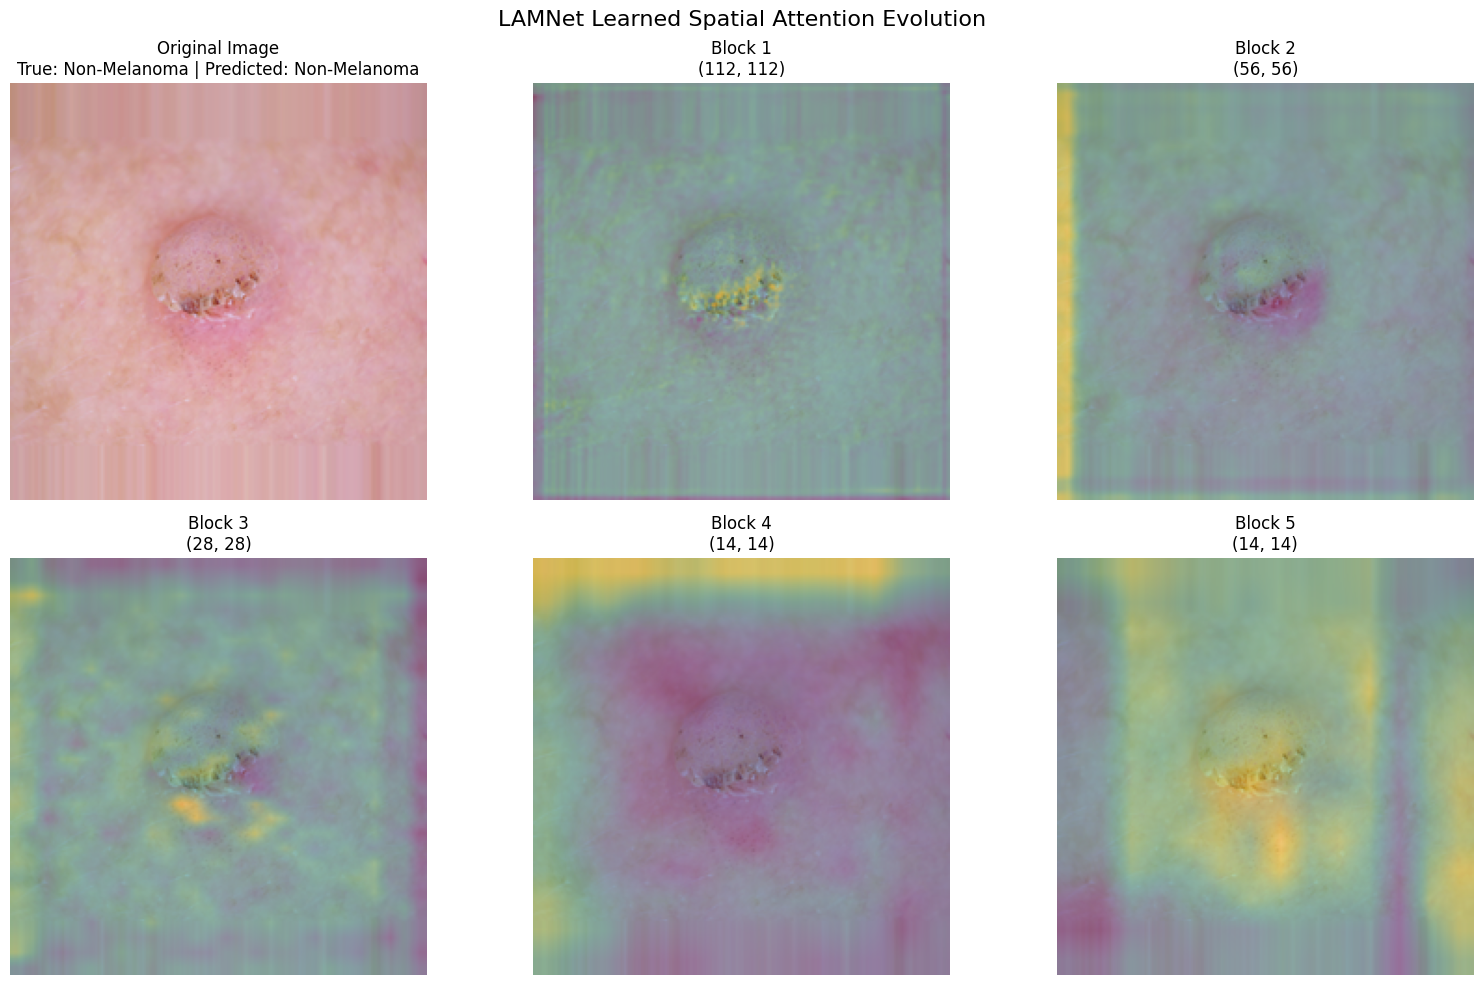

In [20]:
# Visualize the learned LAMNet spatial attention maps across all five blocks

import matplotlib.pyplot as plt
import torch.nn.functional as F

original_image = np.asarray(
    test_dataset.images[sample_index],
    dtype=np.float32
)

original_image = np.clip(original_image, 0.0, 1.0)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 10)
)

axes = axes.flatten()

axes[0].imshow(original_image)
axes[0].set_title(
    f"Original Image\n"
    f"True: {class_names[true_label]} | "
    f"Predicted: {class_names[predicted_label]}"
)
axes[0].axis("off")

for plot_index, block_name in enumerate(
    ["block1", "block2", "block3", "block4", "block5"],
    start=1
):
    attention = attention_maps[block_name]

    attention_resized = F.interpolate(
        attention,
        size=(224, 224),
        mode="bilinear",
        align_corners=False
    )

    attention_resized = attention_resized[0, 0].numpy()

    axes[plot_index].imshow(original_image)
    axes[plot_index].imshow(
        attention_resized,
        alpha=0.45
    )

    axes[plot_index].set_title(
        f"{block_name.replace('block', 'Block ')}\n"
        f"{tuple(attention.shape[-2:])}"
    )

    axes[plot_index].axis("off")

plt.suptitle(
    "LAMNet Learned Spatial Attention Evolution",
    fontsize=16
)

plt.tight_layout()
plt.show()